# Predicting Cross-Border Music Diffusion on Spotify

## Business Context

When a song enters a national Spotify chart for the first time, marketing teams face a practical question: which other countries will this song chart in next? Answering this quickly enables targeted ad spend, localized playlist placement, and coordinated rollouts across markets.

This notebook builds a **Top-5 Country Ranker**: given a song's first chart appearance, it predicts the 5 countries most likely to see the song chart within 60 days. The underlying dataset contains 25.1M chart observations spanning 2017–2021 across 62 markets, cleaned and feature-engineered into ~3.46M (track, target_country) prediction rows: 272,262 for training (downsampled to 5:1 negative-to-positive ratio), and 1,647,221 / 1,535,867 for validation / testing at full class distribution.

**Why 60 days?** Our EDA shows that 75% of international spread occurs within the first 2–4 weeks after initial charting, with a long tail extending to ~60 days. Beyond that, remaining entries are largely driven by external events (Christmas, TikTok virality, movie soundtracks) rather than organic diffusion patterns. The 60-day window captures most genuine spread events while filtering out noise.

**Why Top-5?** Tracks that spread internationally chart in a median of 5.17 additional countries. k=5 aligns with this empirical distribution: large enough to capture the typical spread footprint, small enough to remain actionable. At k=3, the theoretical recall ceiling is too low (~58%); at k=10, the list loses actionability.

## Technical Approach

We address two prediction tasks:

1. **Country ranking** — which countries will a song chart in? We train a linear baseline (Logistic Regression) and a gradient-boosted model (XGBRanker), then compare.
2. **Timing prediction** — when will it chart there? We train a linear baseline (Linear Regression) and a gradient-boosted model (XGBRegressor), then compare.

For each task, the linear baseline establishes what simple decision boundaries can capture and provides interpretable coefficients, while the gradient-boosted model captures non-linear feature interactions.

| Model | Task | Type | Purpose |
|-------|------|------|---------|
| Naive popularity baseline | Ranking | Heuristic | Lower bound: always predict the 5 most popular countries |
| Logistic Regression | Ranking | Linear baseline | Linear ceiling; interpretable coefficients |
| XGBRanker | Ranking | Primary model | Listwise ranking with `rank:ndcg` |
| Linear Regression | Timing | Linear baseline | Linear ceiling for days-to-entry |
| XGBRegressor | Timing | Primary model | Non-linear timing prediction with target transforms |

### Why XGBoost?

We use XGBoost because it supports listwise ranking natively (`XGBRanker` with `rank:ndcg`) and performs well on heterogeneous tabular data with mixed feature types (Grinsztajn et al., 2022). It also handles the 19.4% missing cultural distance data gracefully through learned split behavior on imputed vs observed values. LightGBM's `lambdarank` is a viable alternative but offered no clear advantage for our dataset size.

### Why Learning-to-Rank over Pointwise Classification?

Our task is inherently a ranking problem: given a track, produce an ordered list of countries. A pointwise classifier would predict P(entry) for each (track, country) pair independently, ignoring that predicting "Germany" affects the optimal prediction for "Austria." The listwise XGBRanker with `rank:ndcg` optimizes the ordering directly using group-aware gradients, which aligns with the business need to produce a ranked shortlist.

## Table of Contents

This notebook follows an **approach → metrics → results → selection** structure.

**Setup & Data**
- [1. Setup and Helper Functions](#1.-Setup-and-Helper-Functions) — Temporal split, metrics, scoring utilities
- [2. Feature Selection](#2.-Feature-Selection) — Pruning zero-gain features from prior notebooks

**Methodology**
- [3. Evaluation Metrics](#3.-Evaluation-Metrics-—-Why-These-Metrics?) — Ranking metrics, timing metrics, baselines
- [4. Model Approaches — Overview](#4.-Model-Approaches-—-Overview) — All four models + ablation described before training
  - [4a. Country Ranking Task](#4a.-Country-Ranking-Task) — Logistic Regression + XGBRanker
  - [4b. Timing Prediction Task](#4b.-Timing-Prediction-Task) — Linear Regression + XGBRegressor
  - [4c. Ablation: Pre-Filtering Gate](#4c.-Ablation:-Pre-Filtering-Gate-(Will-Spread-Classifier)) — Will-spread classifier

**Training**
- [5. Model Training](#5.-Model-Training) — All training code grouped together

**Results & Selection**
- [6. Results](#6.-Results-—-How-Does-Each-Model-Perform?)
  - [6a. Country Ranking Results](#6a.-Country-Ranking-Results) — Naive → LR → XGBRanker comparison
  - [6b. Timing Prediction Results](#6b.-Timing-Prediction-Results) — Linear Regression → XGBRegressor comparison
  - [6c. Ablation: Gate vs No Gate](#6c.-Ablation:-Gate-vs-No-Gate) — Recall-cost tradeoff analysis
- [7. Model Selection](#7.-Model-Selection-—-Which-Do-We-Choose?) — Final model choice

**Wrap-up**
- [8. Visualizations](#8.-Visualizations) — Feature importance, coefficients, calibration, bootstrap plots
  - [8a. Language Distribution Analysis](#8a.-Language-Distribution-Analysis) — Is `same_language_flag` an English artifact?
- [9. Artifact Export](#9.-Artifact-Export) — Model files, evaluation parquets, training summary
- [10. Conclusion](#10.-Conclusion) — Findings, limitations, future work

In [1]:
%matplotlib inline
from pathlib import Path
import json
import os
import pickle
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from IPython.display import display
import xgboost as xgb

optuna.logging.set_verbosity(optuna.logging.INFO)
warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 240)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'datasets').exists() and (candidate / 'requirements.txt').exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. Expected a parent containing 'datasets/' and 'requirements.txt'."
    )


ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = ROOT / 'datasets' / 'v3_features'
MODEL_DIR = ROOT / 'artifacts' / 'models' / 'xgboost_final_pipeline'
EVAL_DIR = ROOT / 'artifacts' / 'evaluations' / 'xgboost_final_pipeline'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / 'train.parquet'
VAL_PATH = DATA_DIR / 'val.parquet'
TEST_PATH = DATA_DIR / 'test.parquet'

assert TRAIN_PATH.exists(), f'Missing training split: {TRAIN_PATH}'
assert VAL_PATH.exists(), f'Missing validation split: {VAL_PATH}'
assert TEST_PATH.exists(), f'Missing test split: {TEST_PATH}'

# --- Config ---
RANDOM_STATE = 42
TOP_K = 5

RANKER_N_TRIALS = 50
CLASSIFIER_N_TRIALS = 30
REGRESSOR_N_TRIALS = 30

TIME_BLOCKS = 5
OPTUNA_N_STARTUP_TRIALS = 10
EARLY_STOPPING_ROUNDS = 50
TUNING_N_ESTIMATORS = 2000
FINAL_N_ESTIMATOR_BUFFER = 1.10

PRIMARY_PRECISION_FLOOR = 0.20
BUSINESS_PRECISION_FLOORS = [0.20, 0.25]

# Prior-notebook artifact paths (for feature selection)
NB09_EVAL_DIR = ROOT / 'artifacts' / 'evaluations' / 'xgboost_ranker_temporal_tuned'

print({
    'ranker_n_trials': RANKER_N_TRIALS,
    'classifier_n_trials': CLASSIFIER_N_TRIALS,
    'regressor_n_trials': REGRESSOR_N_TRIALS,
    'time_blocks': TIME_BLOCKS,
    'top_k': TOP_K,
})

/Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'ranker_n_trials': 50, 'classifier_n_trials': 30, 'regressor_n_trials': 30, 'time_blocks': 5, 'top_k': 5}


## 1. Setup and Helper Functions

All shared utilities for data loading, temporal cross-validation, ranking metrics, and model fitting.

### Temporal Train/Validation/Test Split

We split data by the track's first chart date: **train ≤ 2019, validation = 2020, test = 2021**. This strict temporal split is essential because:

- **Preventing data leakage:** Random k-fold CV would allow the model to train on 2021 tracks and predict 2019 tracks — an impossible scenario in production where we only have historical data. Music trends, artist popularity, and platform dynamics evolve over time; a model must prove it generalizes *forward*.
- **Why full calendar years?** Music diffusion is seasonal (holiday releases, summer hits, award season). Year-level splits ensure each split contains a full seasonal cycle, avoiding bias from partial-year effects. Finer splits (e.g., monthly) would introduce boundary artifacts where a track's 60-day prediction horizon crosses the split boundary.
- **Temporal CV within training:** During hyperparameter tuning, we further split the training set (≤2019) into 3 expanding-window folds using `make_temporal_folds()` (5 time blocks → 3 folds). Each fold trains on earlier blocks and validates on the next, maintaining temporal ordering even within the training set.

In [2]:
con = duckdb.connect()

FEATURE_EXCLUDE = ['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry']
TARGET_SPECIFIC_COLS = [
    'artist_prior_success_in_target',
    'target_population',
    'target_avg_daily_streams',
    'target_new_entry_rate_30d',
    'target_continent_africa',
    'target_continent_asia',
    'target_continent_europe',
    'target_continent_north_america',
    'target_continent_oceania',
    'target_continent_south_america',
    'cultural_dist_min',
    'cultural_dist_missing',
    'same_language_flag',
    'same_continent_flag',
    'neighbor_entered_count',
]
EXCLUDE_FROM_TRACK_LEVEL = {'target_country', 'did_enter_within_60d', 'days_to_entry'}


# ── Data loading ──────────────────────────────────────────────────────────────

def load_row_level_split(path: Path, max_tracks: int | None = None) -> pd.DataFrame:
    parquet_path = path.as_posix()
    if max_tracks is None:
        query = f"SELECT * FROM read_parquet('{parquet_path}')"
    else:
        query = f"""
            WITH sampled_tracks AS (
                SELECT track_id
                FROM read_parquet('{parquet_path}')
                GROUP BY track_id
                ORDER BY hash(track_id)
                LIMIT {int(max_tracks)}
            )
            SELECT d.*
            FROM read_parquet('{parquet_path}') d
            JOIN sampled_tracks st USING (track_id)
        """
    df = con.execute(query).fetchdf()
    df['observation_time'] = pd.to_datetime(df['observation_time'])
    return df


def load_track_level_split(path: Path, max_tracks: int | None = None) -> pd.DataFrame:
    parquet_path = path.as_posix()
    schema_df = con.execute(f"SELECT * FROM read_parquet('{parquet_path}') LIMIT 0").fetchdf()
    raw_cols = list(schema_df.columns)
    constant_cols = [c for c in raw_cols if c not in EXCLUDE_FROM_TRACK_LEVEL and c not in TARGET_SPECIFIC_COLS]
    rank_cols = [c for c in raw_cols if c.startswith('rank_')]

    source_expr = f"read_parquet('{parquet_path}')"
    if max_tracks is None:
        source_query = source_expr
    else:
        source_query = f"""
            (
                WITH sampled_tracks AS (
                    SELECT track_id
                    FROM {source_expr}
                    GROUP BY track_id
                    ORDER BY hash(track_id)
                    LIMIT {int(max_tracks)}
                )
                SELECT d.*
                FROM {source_expr} d
                JOIN sampled_tracks st USING (track_id)
            )
        """

    select_parts = [
        'track_id',
        'MAX(CAST(did_enter_within_60d AS INTEGER)) AS will_spread',
        'MIN(CASE WHEN did_enter_within_60d = 1 THEN days_to_entry END) AS min_days_to_spread',
        'COUNT(*) AS candidate_count',
    ]
    select_parts.extend([f'ANY_VALUE({col}) AS {col}' for col in constant_cols if col != 'track_id'])
    for col in TARGET_SPECIFIC_COLS:
        select_parts.append(f'AVG({col}) AS {col}_mean')
        select_parts.append(f'MAX({col}) AS {col}_max')

    query = f"""
        SELECT
            {', '.join(select_parts)}
        FROM {source_query}
        GROUP BY track_id
        ORDER BY track_id
    """
    df = con.execute(query).fetchdf()
    df['observation_time'] = pd.to_datetime(df['observation_time'])
    df['origin_country_count_at_obs'] = (df[rank_cols].fillna(0) > 0).sum(axis=1)
    return df


def make_feature_matrix(df: pd.DataFrame, feature_cols: list[str], fill_values: pd.Series) -> pd.DataFrame:
    return df[feature_cols].copy().fillna(fill_values)


# ── Temporal CV ───────────────────────────────────────────────────────────────

def make_temporal_folds(df: pd.DataFrame, time_blocks: int = 5) -> list[dict]:
    track_times = df[['track_id', 'observation_time']].drop_duplicates().sort_values(
        ['observation_time', 'track_id']
    ).reset_index(drop=True)
    track_times['time_block'] = pd.qcut(track_times.index, q=time_blocks, labels=False, duplicates='drop')
    folds = []
    unique_blocks = sorted(track_times['time_block'].dropna().astype(int).unique())
    for fold_idx, block in enumerate(unique_blocks[2:], start=1):
        train_track_ids = track_times.loc[track_times['time_block'] < block, 'track_id'].tolist()
        val_track_ids = track_times.loc[track_times['time_block'] == block, 'track_id'].tolist()
        if not train_track_ids or not val_track_ids:
            continue
        train_times = track_times.loc[track_times['time_block'] < block, 'observation_time']
        val_times = track_times.loc[track_times['time_block'] == block, 'observation_time']
        folds.append({
            'fold': fold_idx,
            'train_track_ids': train_track_ids,
            'val_track_ids': val_track_ids,
            'train_tracks': len(train_track_ids),
            'val_tracks': len(val_track_ids),
            'train_start': str(train_times.min().date()),
            'train_end': str(train_times.max().date()),
            'val_start': str(val_times.min().date()),
            'val_end': str(val_times.max().date()),
        })
    return folds


# ── Metrics ───────────────────────────────────────────────────────────────────

def safe_roc_auc(y_true, y_score) -> float | None:
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return None
    return float(roc_auc_score(y_true, y_score))


def safe_average_precision(y_true, y_score) -> float | None:
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        return None
    return float(average_precision_score(y_true, y_score))


def binary_metrics(y_true, y_score) -> dict:
    clipped = np.clip(y_score, 1e-6, 1 - 1e-6)
    return {
        'roc_auc': safe_roc_auc(y_true, y_score),
        'average_precision': safe_average_precision(y_true, y_score),
        'log_loss': float(log_loss(y_true, clipped, labels=[0, 1])),
    }


def build_threshold_table(y_true, y_prob, beta: float = 2.0) -> pd.DataFrame:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    rows = []
    beta_sq = beta ** 2
    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        denom = p + r
        f1 = 0.0 if denom == 0 else 2 * p * r / denom
        fbeta = 0.0 if (beta_sq * p + r) == 0 else (1 + beta_sq) * p * r / (beta_sq * p + r)
        predicted_positive_rate = float((y_prob >= t).mean())
        rows.append({
            'threshold': float(t),
            'precision': float(p),
            'recall': float(r),
            'f1': float(f1),
            f'f{beta}': float(fbeta),
            'predicted_positive_rate': predicted_positive_rate,
            'flagged_per_1000_tracks': predicted_positive_rate * 1000.0,
        })
    return pd.DataFrame(rows).sort_values(['threshold']).reset_index(drop=True)


def choose_recall_threshold(y_true, y_prob, precision_floor: float, beta: float = 2.0):
    threshold_df = build_threshold_table(y_true, y_prob, beta=beta)
    eligible = threshold_df[threshold_df['precision'] >= precision_floor].copy()
    if not eligible.empty:
        selected = eligible.sort_values(['recall', 'precision', 'threshold'], ascending=[False, False, True]).iloc[0]
        reason = f'highest recall with precision >= {precision_floor:.2f}'
    else:
        score_col = f'f{beta}'
        selected = threshold_df.sort_values([score_col, 'recall', 'precision'], ascending=[False, False, False]).iloc[0]
        reason = f'fallback to best {score_col} because no threshold met precision floor {precision_floor:.2f}'
    return float(selected['threshold']), threshold_df, reason


def binary_summary(y_true, y_prob, threshold: float, beta: float = 2.0) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    clipped = np.clip(y_prob, 1e-6, 1 - 1e-6)
    return {
        'roc_auc': safe_roc_auc(y_true, y_prob),
        'average_precision': safe_average_precision(y_true, y_prob),
        'log_loss': float(log_loss(y_true, clipped, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, clipped)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        f'f{beta}': float(fbeta_score(y_true, y_pred, beta=beta, zero_division=0)),
        'positive_rate': float(np.mean(y_true)),
        'predicted_positive_rate': float(np.mean(y_pred)),
        'flagged_per_1000_tracks': float(np.mean(y_pred) * 1000.0),
    }


def build_business_threshold_summary(y_true, y_prob, floors: list[float], beta: float = 2.0):
    rows = []
    threshold_tables = []
    threshold_map = {}
    for floor in floors:
        threshold, threshold_df, reason = choose_recall_threshold(y_true, y_prob, precision_floor=floor, beta=beta)
        metrics = binary_summary(y_true, y_prob, threshold=threshold, beta=beta)
        rows.append({
            'precision_floor': float(floor),
            'threshold': float(threshold),
            'selection_reason': reason,
            **metrics,
        })
        threshold_map[float(floor)] = float(threshold)
        threshold_df = threshold_df.copy()
        threshold_df['precision_floor'] = float(floor)
        threshold_tables.append(threshold_df)
    return pd.DataFrame(rows), threshold_map, pd.concat(threshold_tables, ignore_index=True)


def compute_candidate_stats(scored_df: pd.DataFrame) -> dict:
    per_track = scored_df.groupby('track_id').agg(
        candidates=('target_country', 'size'),
        positives=('did_enter_within_60d', 'sum'),
    )
    positive_mask = per_track['positives'] > 0
    return {
        'tracks': int(per_track.shape[0]),
        'positive_tracks': int(positive_mask.sum()),
        'avg_candidates_per_track': float(per_track['candidates'].mean()),
        'avg_future_countries_per_track': float(per_track['positives'].mean()),
        'avg_future_countries_per_positive_track': float(per_track.loc[positive_mask, 'positives'].mean()) if positive_mask.any() else None,
    }


def ranking_metrics(scored_df: pd.DataFrame, k: int = 5) -> tuple[dict, pd.DataFrame]:
    rows = []
    for track_id, group in scored_df.groupby('track_id', sort=False):
        group = group.sort_values(['score', 'tie_break'], ascending=[False, False]).reset_index(drop=True)
        labels = group['did_enter_within_60d'].to_numpy(dtype=int)
        positives = int(labels.sum())
        top = group.head(k)
        top_labels = top['did_enter_within_60d'].to_numpy(dtype=int)
        hits = int(top_labels.sum())

        precision = hits / k
        recall = hits / positives if positives else np.nan
        hit_rate = float(hits > 0) if positives else np.nan

        discounts = np.log2(np.arange(2, len(top_labels) + 2))
        dcg = float(((2 ** top_labels - 1) / discounts).sum())
        ideal = np.sort(labels)[::-1][:len(top_labels)]
        idcg = float(((2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2))).sum())
        ndcg = dcg / idcg if idcg > 0 else np.nan

        ap_accum = 0.0
        running_hits = 0
        for rank, rel in enumerate(top_labels, start=1):
            if rel:
                running_hits += 1
                ap_accum += running_hits / rank
        map_k = ap_accum / min(positives, k) if positives else np.nan

        rows.append({
            'track_id': track_id,
            'positives': positives,
            'top_k_hits': hits,
            f'precision@{k}': precision,
            f'recall@{k}': recall,
            f'hit_rate@{k}': hit_rate,
            f'ndcg@{k}': ndcg,
            f'map@{k}': map_k,
        })

    metric_df = pd.DataFrame(rows)
    positive_mask = metric_df['positives'] > 0
    summary = {
        'tracks': int(metric_df.shape[0]),
        'positive_tracks': int(positive_mask.sum()),
        f'precision@{k}': float(metric_df[f'precision@{k}'].mean()),
        f'recall@{k}': float(metric_df.loc[positive_mask, f'recall@{k}'].mean()) if positive_mask.any() else None,
        f'hit_rate@{k}': float(metric_df.loc[positive_mask, f'hit_rate@{k}'].mean()) if positive_mask.any() else None,
        f'ndcg@{k}': float(metric_df.loc[positive_mask, f'ndcg@{k}'].mean()) if positive_mask.any() else None,
        f'map@{k}': float(metric_df.loc[positive_mask, f'map@{k}'].mean()) if positive_mask.any() else None,
        'mean_future_countries_per_track': float(metric_df['positives'].mean()),
    }
    return summary, metric_df


def evaluate_ranked_candidates(scored_df: pd.DataFrame, k: int = 5) -> tuple[dict, pd.DataFrame]:
    candidate_stats = compute_candidate_stats(scored_df)
    binary = binary_metrics(scored_df['did_enter_within_60d'], scored_df['score'].to_numpy())
    ranking_all, track_metrics = ranking_metrics(scored_df, k=k)
    positive_track_metrics = track_metrics[track_metrics['positives'] > 0].copy()
    positive_summary = {
        'tracks': int(positive_track_metrics.shape[0]),
        'avg_future_countries_per_positive_track': float(positive_track_metrics['positives'].mean()) if not positive_track_metrics.empty else None,
        f'avg_top_{k}_hits_per_positive_track': float(positive_track_metrics['top_k_hits'].mean()) if not positive_track_metrics.empty else None,
        f'recall@{k}': float(positive_track_metrics[f'recall@{k}'].mean()) if not positive_track_metrics.empty else None,
        f'hit_rate@{k}': float(positive_track_metrics[f'hit_rate@{k}'].mean()) if not positive_track_metrics.empty else None,
        f'ndcg@{k}': float(positive_track_metrics[f'ndcg@{k}'].mean()) if not positive_track_metrics.empty else None,
        f'map@{k}': float(positive_track_metrics[f'map@{k}'].mean()) if not positive_track_metrics.empty else None,
    }
    return {
        'binary': binary,
        'candidate_stats': candidate_stats,
        'ranking_all_tracks': ranking_all,
        'ranking_positive_tracks': positive_summary,
    }, track_metrics


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    abs_err = np.abs(y_true - y_pred)
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'median_ae': float(median_absolute_error(y_true, y_pred)),
        'pct_within_3_days': float(np.mean(abs_err <= 3.0)),
        'pct_within_7_days': float(np.mean(abs_err <= 7.0)),
    }


# ── Scoring helpers ──────────────────────────────────────────────────────────

def normalize_scores(values: pd.Series) -> pd.Series:
    value_min = float(values.min())
    value_max = float(values.max())
    if value_max > value_min:
        return (values - value_min) / (value_max - value_min)
    return pd.Series(np.full(len(values), 0.5), index=values.index)


def score_naive_popularity(df: pd.DataFrame) -> pd.DataFrame:
    scored = df[['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry', 'target_avg_daily_streams', 'target_new_entry_rate_30d']].copy()
    primary = scored['target_avg_daily_streams'].fillna(0.0)
    tie_break = scored['target_new_entry_rate_30d'].fillna(0.0)
    raw_score = primary + tie_break * 1e-6
    scored['score'] = normalize_scores(raw_score)
    scored['tie_break'] = tie_break
    scored['model_name'] = 'naive_popularity_baseline'
    return scored


def feature_category(name: str) -> str:
    if name.startswith('rank_') or name in {'track_in_viral50_at_obs', 'candidate_count', 'origin_country_count_at_obs'}:
        return 'current_footprint'
    if name.startswith('artist_') or name == 'multi_artist_flag':
        return 'artist_history'
    if name.startswith('target_'):
        return 'target_country_priors'
    if name in {'cultural_dist_min', 'cultural_dist_missing', 'same_language_flag', 'song_lang_matches_target', 'same_continent_flag', 'neighbor_entered_count'}:
        return 'origin_target_relationship'
    if name.endswith('_mean') or name.endswith('_max'):
        return 'aggregates'
    if name.startswith('af_') or name in {'duration_ms', 'explicit', 'days_since_release', 'is_friday_release'}:
        return 'audio_track_metadata'
    if name.startswith('observation_'):
        return 'temporal'
    return 'other'


# ── Ranker helpers ────────────────────────────────────────────────────────────

def prepare_ranker_inputs(df: pd.DataFrame, feature_cols: list[str], fill_values: pd.Series):
    ordered = df.sort_values(['track_id', 'target_country']).reset_index(drop=True)
    X = make_feature_matrix(ordered, feature_cols, fill_values)
    y = ordered['did_enter_within_60d'].astype(float).to_numpy()
    group = ordered.groupby('track_id', sort=False).size().to_numpy()
    return ordered, X, y, group


def make_ranker(params: dict, n_estimators: int = TUNING_N_ESTIMATORS, early_stopping_rounds: int | None = EARLY_STOPPING_ROUNDS):
    init_kwargs = {
        'objective': 'rank:ndcg',
        'eval_metric': f'ndcg@{TOP_K}',
        'tree_method': 'hist',
        'n_estimators': n_estimators,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        **params,
    }
    if early_stopping_rounds is not None:
        init_kwargs['early_stopping_rounds'] = early_stopping_rounds
    return xgb.XGBRanker(**init_kwargs)


def score_ranker(model, df: pd.DataFrame, feature_cols: list[str], fill_values: pd.Series, model_name: str) -> pd.DataFrame:
    ordered = df.sort_values(['track_id', 'target_country']).reset_index(drop=True)
    X = make_feature_matrix(ordered, feature_cols, fill_values)
    raw_scores = pd.Series(model.predict(X), index=ordered.index)
    scored = ordered[['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry', 'target_avg_daily_streams', 'target_new_entry_rate_30d']].copy()
    scored['score'] = normalize_scores(raw_scores)
    scored['raw_score'] = raw_scores.to_numpy()
    scored['tie_break'] = scored['target_new_entry_rate_30d'].fillna(0.0)
    scored['model_name'] = model_name
    return scored


def fit_ranker_with_validation(train_part, val_part, feature_cols, fill_values, params):
    _, X_train, y_train, group_train = prepare_ranker_inputs(train_part, feature_cols, fill_values)
    _, X_val, y_val, group_val = prepare_ranker_inputs(val_part, feature_cols, fill_values)
    model = make_ranker(params)
    model.fit(X_train, y_train, group=group_train, eval_set=[(X_val, y_val)], eval_group=[group_val], verbose=False)
    return model


def fit_final_ranker(train_part, feature_cols, fill_values, params, n_estimators):
    _, X_train, y_train, group_train = prepare_ranker_inputs(train_part, feature_cols, fill_values)
    model = make_ranker(params, n_estimators=n_estimators, early_stopping_rounds=None)
    model.fit(X_train, y_train, group=group_train, verbose=False)
    return model


# ── Regressor helpers ─────────────────────────────────────────────────────────

def transform_target(y, target_transform: str) -> np.ndarray:
    y_arr = np.asarray(y, dtype=float)
    if target_transform == 'log1p':
        return np.log1p(y_arr)
    if target_transform == 'sqrt':
        return np.sqrt(y_arr)
    return y_arr


def inverse_transform_target(y: np.ndarray, target_transform: str) -> np.ndarray:
    y_arr = np.asarray(y, dtype=float)
    if target_transform == 'log1p':
        return np.expm1(y_arr)
    if target_transform == 'sqrt':
        return np.square(y_arr)
    return y_arr


def make_regressor(params: dict, n_estimators: int = 800, early_stopping_rounds: int | None = 30):
    init_kwargs = {
        'objective': 'reg:squarederror',
        'eval_metric': 'mae',
        'tree_method': 'hist',
        'n_estimators': n_estimators,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        **params,
    }
    if early_stopping_rounds is not None:
        init_kwargs['early_stopping_rounds'] = early_stopping_rounds
    return xgb.XGBRegressor(**init_kwargs)


def score_regressor(model, df, feature_cols, fill_values, target_transform='identity'):
    preds = model.predict(make_feature_matrix(df, feature_cols, fill_values))
    preds = inverse_transform_target(preds, target_transform)
    scored = df[['track_id', 'observation_time', 'target_country', 'did_enter_within_60d', 'days_to_entry']].copy()
    scored['predicted_days_to_entry'] = np.clip(preds, 1.0, 60.0)
    return scored


# ── Pipeline integration helpers ──────────────────────────────────────────────

def add_stage1_to_row_predictions(row_scored_df, stage1_scored_df, threshold_map):
    merged = row_scored_df.merge(
        stage1_scored_df[['track_id', 'score']].rename(columns={'score': 'spread_score'}),
        on='track_id', how='left',
    )
    for floor, threshold in threshold_map.items():
        col = f'spread_decision_floor_{float(floor):.2f}'.replace('.', '_')
        merged[col] = (merged['spread_score'] >= float(threshold)).astype(int)
    return merged


def add_regression_predictions(row_scored_df, reg_scored_df):
    return row_scored_df.merge(
        reg_scored_df[['track_id', 'target_country', 'predicted_days_to_entry']],
        on=['track_id', 'target_country'], how='left',
    )


def add_predicted_rank(scored_df):
    ranked = scored_df.sort_values(['track_id', 'score', 'target_new_entry_rate_30d'], ascending=[True, False, False]).copy()
    ranked['predicted_rank'] = ranked.groupby('track_id').cumcount().add(1).astype(int)
    return ranked


def evaluate_gated_pipeline(scored_df, gate_col, k=5):
    rows = []
    hit_rows = []
    topk_rows = []
    for track_id, group in scored_df.groupby('track_id', sort=False):
        group = group.sort_values(['score', 'target_new_entry_rate_30d'], ascending=[False, False]).reset_index(drop=True)
        labels = group['did_enter_within_60d'].to_numpy(dtype=int)
        positives = int(labels.sum())
        gated = bool(group[gate_col].iloc[0]) if not group.empty else False
        top = group.head(k).copy() if gated else group.head(0).copy()
        top_labels = top['did_enter_within_60d'].to_numpy(dtype=int)
        hits = int(top_labels.sum())

        precision = hits / k
        recall = hits / positives if positives else np.nan
        hit_rate = float(hits > 0) if positives else np.nan

        discounts = np.log2(np.arange(2, len(top_labels) + 2)) if len(top_labels) else np.array([])
        dcg = float(((2 ** top_labels - 1) / discounts).sum()) if len(top_labels) else 0.0
        ideal = np.sort(labels)[::-1][:k]
        idcg = float(((2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2))).sum()) if positives else 0.0
        ndcg = dcg / idcg if idcg > 0 else np.nan

        ap_accum = 0.0
        running_hits = 0
        for rank, rel in enumerate(top_labels, start=1):
            if rel:
                running_hits += 1
                ap_accum += running_hits / rank
        map_k = ap_accum / min(positives, k) if positives else np.nan

        rows.append({
            'track_id': track_id, 'positives': positives, 'stage1_flagged': int(gated),
            'top_k_hits': hits, f'precision@{k}': precision, f'recall@{k}': recall,
            f'hit_rate@{k}': hit_rate, f'ndcg@{k}': ndcg, f'map@{k}': map_k,
        })
        if not top.empty:
            topk_rows.append(top)
            hits_df = top[top['did_enter_within_60d'] == 1].copy()
            if not hits_df.empty:
                hit_rows.append(hits_df)

    metric_df = pd.DataFrame(rows)
    positive_mask = metric_df['positives'] > 0
    summary = {
        'tracks': int(metric_df.shape[0]),
        'positive_tracks': int(positive_mask.sum()),
        'flagged_tracks': int(metric_df['stage1_flagged'].sum()),
        f'precision@{k}': float(metric_df[f'precision@{k}'].mean()),
        f'recall@{k}': float(metric_df.loc[positive_mask, f'recall@{k}'].mean()) if positive_mask.any() else None,
        f'hit_rate@{k}': float(metric_df.loc[positive_mask, f'hit_rate@{k}'].mean()) if positive_mask.any() else None,
        f'ndcg@{k}': float(metric_df.loc[positive_mask, f'ndcg@{k}'].mean()) if positive_mask.any() else None,
        f'map@{k}': float(metric_df.loc[positive_mask, f'map@{k}'].mean()) if positive_mask.any() else None,
    }
    topk_df = pd.concat(topk_rows, ignore_index=True) if topk_rows else scored_df.head(0).copy()
    hit_df = pd.concat(hit_rows, ignore_index=True) if hit_rows else scored_df.head(0).copy()
    if not hit_df.empty:
        day_metrics = regression_metrics(hit_df['days_to_entry'].astype(float).to_numpy(), hit_df['predicted_days_to_entry'].astype(float).to_numpy())
        day_metrics['evaluated_rows'] = int(len(hit_df))
    else:
        day_metrics = {'mae': None, 'rmse': None, 'median_ae': None, 'pct_within_3_days': None, 'pct_within_7_days': None, 'evaluated_rows': 0}
    return summary, metric_df, day_metrics, topk_df



def fit_regressor_with_validation(train_pos, val_pos, feature_cols, fill_values, params, target_transform='identity'):
    X_train = make_feature_matrix(train_pos, feature_cols, fill_values)
    y_train = transform_target(train_pos['days_to_entry'].astype(float), target_transform)
    X_val = make_feature_matrix(val_pos, feature_cols, fill_values)
    y_val = transform_target(val_pos['days_to_entry'].astype(float), target_transform)
    model = make_regressor(params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model


def fit_final_regressor(train_pos, feature_cols, fill_values, params, n_estimators, target_transform='identity'):
    X_train = make_feature_matrix(train_pos, feature_cols, fill_values)
    y_train = transform_target(train_pos['days_to_entry'].astype(float), target_transform)
    model = make_regressor(params, n_estimators=n_estimators, early_stopping_rounds=None)
    model.fit(X_train, y_train, verbose=False)
    return model


print('All helper functions defined.')


All helper functions defined.


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────

row_train_df = load_row_level_split(TRAIN_PATH)
row_val_df = load_row_level_split(VAL_PATH)
row_test_df = load_row_level_split(TEST_PATH)

track_train_df = load_track_level_split(TRAIN_PATH)
track_val_df = load_track_level_split(VAL_PATH)
track_test_df = load_track_level_split(TEST_PATH)

# Row-level features (one row per track x target_country pair)
row_feature_cols = [col for col in row_train_df.columns if col not in FEATURE_EXCLUDE]
row_fill_values_train = row_train_df[row_feature_cols].median(numeric_only=True)
row_fill_values_final = pd.concat([row_train_df, row_val_df], ignore_index=True)[row_feature_cols].median(numeric_only=True)

# Track-level features (one row per track, for the classifier ablation)
track_feature_exclude = ['track_id', 'observation_time', 'will_spread', 'min_days_to_spread']
track_feature_cols = [col for col in track_train_df.columns if col not in track_feature_exclude]
track_fill_values = track_train_df[track_feature_cols].median(numeric_only=True)

# Temporal CV folds: 5 time blocks → 3 expanding-window folds (shared across all stages)
time_folds = make_temporal_folds(row_train_df, time_blocks=TIME_BLOCKS)

# Positive rows for the days-to-entry regressor
positive_train_rows = row_train_df[(row_train_df['did_enter_within_60d'] == 1) & row_train_df['days_to_entry'].notna()].copy()
positive_val_rows = row_val_df[(row_val_df['did_enter_within_60d'] == 1) & row_val_df['days_to_entry'].notna()].copy()
positive_test_rows = row_test_df[(row_test_df['did_enter_within_60d'] == 1) & row_test_df['days_to_entry'].notna()].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
train_tracks = row_train_df['track_id'].nunique()
val_tracks = row_val_df['track_id'].nunique()
test_tracks = row_test_df['track_id'].nunique()
spread_rate = track_train_df['will_spread'].mean() * 100

print('=== Dataset Overview ===')
print(f'Temporal split: train (2017-2019) → val (2020) → test (2021)')
print(f'  Train: {len(row_train_df):>10,} rows | {train_tracks:>6,} tracks')
print(f'  Val:   {len(row_val_df):>10,} rows | {val_tracks:>6,} tracks')
print(f'  Test:  {len(row_test_df):>10,} rows | {test_tracks:>6,} tracks')
print(f'  Features: {len(row_feature_cols)} per (track, country) pair')
print()
print(f'Only {spread_rate:.1f}% of tracks spread to at least one new country within 60 days.')
print(f'Spreading tracks enter {track_train_df.loc[track_train_df["will_spread"]==1, "candidate_count"].mean():.0f} candidate markets on average.')
print()
print('Temporal CV folds (training data only):')
display(pd.DataFrame([{k: v for k, v in f.items() if k not in ('train_track_ids', 'val_track_ids')} for f in time_folds]))

=== Dataset Overview ===
Temporal split: train (2017-2019) → val (2020) → test (2021)
  Train:    267,809 rows | 63,277 tracks
  Val:    1,486,007 rows | 24,887 tracks
  Test:   1,365,875 rows | 22,818 tracks
  Features: 104 per (track, country) pair

Only 12.4% of tracks spread to at least one new country within 60 days.
Spreading tracks enter 9 candidate markets on average.

Temporal CV folds (training data only):


,fold,train_tracks,val_tracks,train_start,train_end,val_start,val_end
0,1,25311,12655,2017-01-01,2018-04-04,2018-04-04,2018-11-09
1,2,37966,12655,2017-01-01,2018-11-09,2018-11-09,2019-06-14
2,3,50621,12656,2017-01-01,2019-06-14,2019-06-14,2019-12-31


## 2. Feature Selection

Our feature matrix contains ~106 features per (track, target_country) pair, covering cultural distance, geographic proximity, artist history, chart momentum, and temporal patterns. Not all features contribute equally — prior experiments revealed that many small-country rank columns and niche cultural indicators carry zero predictive gain.

The pruning is based on **Notebook 09** (`xgboost_ranker_temporal_tuned`), which trained an XGBRanker with temporal cross-validation on the country-ranking task and exported per-feature gain scores. Features that received exactly zero gain — meaning the model never selected them for a split — are removed from the row-level feature set used by both the Stage 2 ranker and Stage 3 regressor. This drops 2 features (`rank_andorra`, `target_continent_antarctica`). The track-level feature set used by the Stage 1 will-spread ablation is left unpruned, since that classifier is not part of the production pipeline and pruning based on a different model's importance would not be justified.

We apply a **conservative pruning strategy**: remove only features where the trained model assigned exactly zero importance (gain = 0). This eliminates noise dimensions without risking information loss, and reduces training time for hyperparameter optimization.

In [4]:
# ── Row-level feature pruning (Stage 2 ranker + Stage 3 regressor) ────────────
nb09_importance_path = NB09_EVAL_DIR / 'feature_importance.parquet'
assert nb09_importance_path.exists(), f'Missing NB09 importance: {nb09_importance_path}'

nb09_importance = con.execute(f"SELECT * FROM read_parquet('{nb09_importance_path.as_posix()}')").fetchdf()
zero_gain_row = nb09_importance[nb09_importance['gain'] == 0.0]['feature'].tolist()

pruned_row_feature_cols = [col for col in row_feature_cols if col not in zero_gain_row]
print(f'Row-level features: {len(row_feature_cols)} → {len(pruned_row_feature_cols)} (dropped {len(zero_gain_row)} zero-gain)')
print(f'Dropped: {zero_gain_row}')

# Update fill values to match pruned feature set
pruned_row_fill_values_train = row_fill_values_train[pruned_row_feature_cols]
pruned_row_fill_values_final = row_fill_values_final[pruned_row_feature_cols]

print(f'\nTrack-level features: {len(track_feature_cols)} (no pruning — ablation only, not used in production)')

Row-level features: 104 → 102 (dropped 2 zero-gain)
Dropped: ['rank_andorra', 'target_continent_antarctica']

Track-level features: 121 (no pruning — ablation only, not used in production)


**Interpretation:** Feature pruning removed 2 zero-gain features (`rank_andorra`, `target_continent_antarctica`) from 104 → 102. Both are uninformative: Andorra's market is too small to carry signal, and Antarctica is a one-hot encoding artifact. The remaining 102 features are used by the Stage 2 ranker and Stage 3 regressor. Track-level features (Stage 1 ablation only) are left unpruned.

## 3. Evaluation Metrics

We define all evaluation metrics before training to ensure model development is guided by pre-specified criteria rather than post-hoc metric selection.

### Ranking Metrics (Country Prediction Task)

- **recall@k:** Of all countries a track actually charted in, what fraction appeared in our top-k? Directly measures whether the model would target the right markets. We use k=5, aligned with the median spread of 5.17 countries.
- **ndcg@k (Normalized Discounted Cumulative Gain):** Are the most relevant countries ranked higher? Measures ranking quality, not just set membership. Important because marketing teams act on the *order* of predictions: the #1 predicted market gets more resources than #5.
- **hit_rate@k:** For what fraction of tracks does at least one prediction hit? Measures broad reliability across the track population.
- **MAP@k (Mean Average Precision):** Rewards placing correct countries earlier in the ranked list. Uses binary relevance and averages precision at each relevant position.

### Timing Metrics (Days-to-Entry Prediction Task)

- **MAE (Mean Absolute Error):** Average days off. Preferred over RMSE for business communication because it is directly interpretable.
- **% within 3 days / 7 days:** Operationally meaningful thresholds. A prediction within 3 days enables tight campaign coordination; within 7 days enables weekly planning cycles.

### Baselines

- **Naive popularity baseline (ranking):** Always predict the 5 globally most popular countries (by average daily streams). Any useful model must substantially outperform this.
- **Linear baselines (both tasks):** Logistic Regression for ranking, Linear Regression for timing. These establish what linear decision boundaries can capture and quantify the value of non-linear modeling.

### Why Not Accuracy or F1?

Given the 110:1 class imbalance (only ~0.9% of track x country pairs result in chart entry), a model predicting "no entry" everywhere achieves 99.1% accuracy. Ranking metrics on the top-k are more meaningful for our use case: we always produce exactly k=5 predictions per track, and we care about the set and order of those predictions, not a binary decision boundary.

## 4. Model Approaches — Overview

This section describes all models before showing any results. We present two tasks (ranking and timing), each with a linear baseline and a gradient-boosted primary model, plus one ablation study.

### 4a. Country Ranking Task

**Logistic Regression (linear baseline):**
- StandardScaler + `class_weight='balanced'` to handle the ~16.7% positive rate in the downsampled training set
- Countries ranked by P(did_enter_within_60d = 1), a pointwise-to-ranking approach
- **Purpose:** (a) establishes what linear decision boundaries can capture, and (b) provides directional coefficient interpretation (e.g., "a one-standard-deviation increase in cultural distance decreases the log-odds of charting by X")

**XGBRanker (primary model):**
- `rank:ndcg` listwise objective, directly optimizing the ordering of candidate countries per track
- Optuna TPE sampler (50 trials) with temporal cross-validation (3 expanding-window folds)
- MedianPruner to early-stop unpromising trials after fold 1
- 8 hyperparameters: learning rate, max depth, min child weight, subsample, colsample, gamma, L1/L2 regularization
- **Purpose:** captures non-linear feature interactions (e.g., "high cultural distance BUT prior artist presence" may override the barrier)

### 4b. Timing Prediction Task

Both timing models are trained on **positive rows only**, i.e. tracks that actually entered the target country's chart. The regression target is `days_to_entry` (1–60 days).

**Linear Regression (linear baseline):**
- StandardScaler, trained on positive rows
- **Purpose:** establishes the linear ceiling for timing prediction; reveals which features linearly correlate with faster or slower spread

**XGBRegressor (primary model):**
- Optuna-tuned with target transform selection (identity / log1p / sqrt); the right-skewed distribution of days_to_entry benefits from variance-stabilizing transforms
- 30 trials with temporal CV on positive rows
- **Purpose:** captures non-linear timing patterns (e.g., culturally close markets are entered fast only when the artist also has prior presence there)

### 4c. Ablation: Pre-Filtering Gate (Will-Spread Classifier)

Can a pre-filtering gate reduce inference cost by first predicting whether a track will spread, then only running the ranker on flagged tracks?

- XGBClassifier with isotonic calibration (to correct poorly-calibrated probabilities under 87.5% class imbalance)
- 30 Optuna trials with temporal CV
- Evaluated at multiple precision floors (0.20, 0.25) to quantify the recall-cost tradeoff

## 5. Model Training

All training code is grouped in this section. Results interpretation follows in Section 6.

In [5]:
# ── Logistic Regression Baseline ──────────────────────────────────────────────

# Prepare features
X_train_lr = make_feature_matrix(row_train_df, pruned_row_feature_cols, pruned_row_fill_values_train)
y_train_lr = row_train_df['did_enter_within_60d'].to_numpy()

X_test_lr = make_feature_matrix(row_test_df, pruned_row_feature_cols, pruned_row_fill_values_final)
X_val_lr = make_feature_matrix(row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train)

# Standardize features (fit on train only to prevent leakage)
lr_scaler = StandardScaler()
X_train_lr_scaled = lr_scaler.fit_transform(X_train_lr)
X_val_lr_scaled = lr_scaler.transform(X_val_lr)
X_test_lr_scaled = lr_scaler.transform(X_test_lr)

# Train logistic regression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lr_model.fit(X_train_lr_scaled, y_train_lr)
print(f'Logistic Regression fitted: {lr_model.n_features_in_} features, converged in {lr_model.n_iter_[0]} iterations')

# Score validation and test sets — rank countries by P(spread)
def score_logistic_regression(model, scaler, df, feature_cols, fill_values, model_name):
    """Score a logistic regression model and format output for ranking evaluation."""
    ordered = df.sort_values(['track_id', 'target_country']).reset_index(drop=True)
    X = make_feature_matrix(ordered, feature_cols, fill_values)
    X_scaled = scaler.transform(X)
    proba = model.predict_proba(X_scaled)[:, 1]
    scored = ordered[['track_id', 'observation_time', 'target_country',
                       'did_enter_within_60d', 'days_to_entry',
                       'target_avg_daily_streams', 'target_new_entry_rate_30d']].copy()
    scored['score'] = normalize_scores(pd.Series(proba, index=ordered.index))
    scored['raw_score'] = proba
    scored['tie_break'] = scored['target_new_entry_rate_30d'].fillna(0.0)
    scored['model_name'] = model_name
    return scored

lr_val_scored = score_logistic_regression(
    lr_model, lr_scaler, row_val_df,
    pruned_row_feature_cols, pruned_row_fill_values_train, 'logistic_regression_val'
)
lr_test_scored = score_logistic_regression(
    lr_model, lr_scaler, row_test_df,
    pruned_row_feature_cols, pruned_row_fill_values_final, 'logistic_regression_test'
)

lr_val_results, _ = evaluate_ranked_candidates(lr_val_scored, k=TOP_K)
lr_test_results, _ = evaluate_ranked_candidates(lr_test_scored, k=TOP_K)

# ── Baseline comparison table ────────────────────────────────────────────────

baseline_test_scored = score_naive_popularity(row_test_df)
baseline_test_results, _ = evaluate_ranked_candidates(baseline_test_scored, k=TOP_K)

lr_comparison = pd.DataFrame([
    {'split': 'validation', 'model': 'logistic_regression',
     f'recall@{TOP_K}': lr_val_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': lr_val_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': lr_val_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': lr_val_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'logistic_regression',
     f'recall@{TOP_K}': lr_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': lr_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': lr_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': lr_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'naive_popularity',
     f'recall@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
])
print()
print('Baseline model comparison:')
display(lr_comparison)

Logistic Regression fitted: 102 features, converged in 30 iterations

Baseline model comparison:


,split,model,recall@5,ndcg@5,hit_rate@5,map@5
0,validation,logistic_regression,0.597010,0.624637,0.819770,0.561333
1,test,logistic_regression,0.601354,0.622029,0.823805,0.557053
2,test,naive_popularity,0.073849,0.109321,0.249480,0.081402


In [6]:
# ── Logistic Regression Feature Coefficients ─────────────────────────────────

# Extract coefficients (standardized — directly comparable across features)
lr_coef_df = pd.DataFrame({
    'feature': pruned_row_feature_cols,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0]),
    'category': [feature_category(f) for f in pruned_row_feature_cols],
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

print('Top 20 most influential features (Logistic Regression, standardized coefficients):')
print('Positive = increases probability of charting in target country')
print('Negative = decreases probability of charting in target country')
print()
display(lr_coef_df.head(20)[['feature', 'coefficient', 'category']])

# Category-level summary: mean absolute coefficient per category
lr_category_summary = (
    lr_coef_df.groupby('category')['abs_coefficient']
    .agg(['mean', 'sum', 'count'])
    .sort_values('sum', ascending=False)
    .rename(columns={'mean': 'avg_abs_coef', 'sum': 'total_abs_coef', 'count': 'n_features'})
)
print()
print('Feature importance by category (Logistic Regression):')
display(lr_category_summary)

# ── Coefficient direction analysis for business interpretation ────────────────

print()
print('Key feature directions (business interpretation):')
key_features = [
    'cultural_dist_min', 'same_language_flag', 'same_continent_flag',
    'neighbor_entered_count', 'artist_prior_success_in_target',
    'target_avg_daily_streams', 'target_new_entry_rate_30d',
    'artist_prior_unique_regions', 'artist_country_ratio',
]
for feat in key_features:
    row = lr_coef_df[lr_coef_df['feature'] == feat]
    if not row.empty:
        coef = float(row['coefficient'].iloc[0])
        direction = 'increases' if coef > 0 else 'decreases'
        print(f'  {feat}: {coef:+.4f} → {direction} spread probability')

Top 20 most influential features (Logistic Regression, standardized coefficients):
Positive = increases probability of charting in target country
Negative = decreases probability of charting in target country



,feature,coefficient,category
0,artist_prior_unique_regions,0.844238,artist_history
1,target_continent_north_america,-0.698020,target_country_priors
2,target_continent_south_america,-0.667319,target_country_priors
3,target_continent_europe,-0.655639,target_country_priors
4,artist_prior_success_in_target,0.561001,artist_history
5,song_lang_matches_target,0.539372,other
6,target_continent_asia,-0.442626,target_country_priors
7,artist_prior_best_rank,0.439084,artist_history
8,same_language_flag,0.420568,origin_target_relationship
9,same_continent_flag,0.377754,origin_target_relationship



Feature importance by category (Logistic Regression):


,avg_abs_coef,total_abs_coef,n_features
category,,,
current_footprint,0.065872,4.084035,62
target_country_priors,0.395648,3.560830,9
artist_history,0.345547,2.418829,7
audio_track_metadata,0.103037,1.648590,16
origin_target_relationship,0.226819,1.134095,5
other,0.539372,0.539372,1
temporal,0.116673,0.233345,2



Key feature directions (business interpretation):
  cultural_dist_min: -0.1637 → decreases spread probability
  same_language_flag: +0.4206 → increases spread probability
  same_continent_flag: +0.3778 → increases spread probability
  neighbor_entered_count: +0.0961 → increases spread probability
  artist_prior_success_in_target: +0.5610 → increases spread probability
  target_avg_daily_streams: +0.0077 → increases spread probability
  target_new_entry_rate_30d: +0.1583 → increases spread probability
  artist_prior_unique_regions: +0.8442 → increases spread probability
  artist_country_ratio: +0.0940 → increases spread probability


In [7]:
# ── Optuna objective for Stage 2 ranker ────────────────────────────────────────

stage2_trial_records = []
stage2_fold_records = []


def ranker_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 100.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
    }

    fold_ndcgs = []
    fold_summaries = []
    for fold_idx, fold in enumerate(time_folds):
        fold_train = row_train_df[row_train_df['track_id'].isin(fold['train_track_ids'])].copy()
        fold_val = row_train_df[row_train_df['track_id'].isin(fold['val_track_ids'])].copy()
        fold_fill = fold_train[pruned_row_feature_cols].median(numeric_only=True)

        _, X_train, y_train, group_train = prepare_ranker_inputs(fold_train, pruned_row_feature_cols, fold_fill)
        _, X_val, y_val, group_val = prepare_ranker_inputs(fold_val, pruned_row_feature_cols, fold_fill)

        model = make_ranker(params)
        model.fit(X_train, y_train, group=group_train,
                  eval_set=[(X_val, y_val)], eval_group=[group_val], verbose=False)

        scored_val = score_ranker(model, fold_val, pruned_row_feature_cols, fold_fill, 'xgb_ranker_fold')
        summary, _ = evaluate_ranked_candidates(scored_val, k=TOP_K)
        best_iter = getattr(model, 'best_iteration', None)
        resolved_rounds = int(best_iter + 1) if best_iter is not None else TUNING_N_ESTIMATORS

        ndcg = summary['ranking_all_tracks'][f'ndcg@{TOP_K}']
        fold_ndcgs.append(ndcg)

        fold_record = {
            'trial_label': f'optuna_{trial.number:03d}',
            'fold': fold['fold'],
            'best_iteration': resolved_rounds,
            f'ndcg@{TOP_K}': ndcg,
            f'recall@{TOP_K}': summary['ranking_all_tracks'][f'recall@{TOP_K}'],
            f'map@{TOP_K}': summary['ranking_all_tracks'][f'map@{TOP_K}'],
            'roc_auc': summary['binary']['roc_auc'],
        }
        fold_summaries.append(fold_record)
        stage2_fold_records.append(fold_record | params)

        # Report intermediate value for pruning
        trial.report(np.mean(fold_ndcgs), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    fold_df = pd.DataFrame(fold_summaries)
    record = {
        'trial_label': f'optuna_{trial.number:03d}',
        'mean_best_iteration': float(fold_df['best_iteration'].mean()),
        f'mean_ndcg@{TOP_K}': float(fold_df[f'ndcg@{TOP_K}'].mean()),
        f'mean_recall@{TOP_K}': float(fold_df[f'recall@{TOP_K}'].mean()),
        f'mean_map@{TOP_K}': float(fold_df[f'map@{TOP_K}'].mean()),
        'mean_roc_auc': float(fold_df['roc_auc'].mean()),
        **params,
    }
    stage2_trial_records.append(record)
    return record[f'mean_ndcg@{TOP_K}']


stage2_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=OPTUNA_N_STARTUP_TRIALS, n_warmup_steps=0),
)
stage2_study.optimize(ranker_objective, n_trials=RANKER_N_TRIALS, show_progress_bar=True)

stage2_best_params = stage2_study.best_params
stage2_trial_df = pd.DataFrame(stage2_trial_records).sort_values(f'mean_ndcg@{TOP_K}', ascending=False).reset_index(drop=True)
stage2_fold_df = pd.DataFrame(stage2_fold_records)

print(f'Best ranker params (ndcg@{TOP_K} = {stage2_study.best_value:.6f}):')
print(json.dumps(stage2_best_params, indent=2))
print()
print('Top 10 trials:')
display(stage2_trial_df.head(10))

[I 2026-03-18 22:49:03,856] A new study created in memory with name: no-name-49d41b61-bd6f-4257-951c-1a17329fe36c
Best trial: 0. Best value: 0.949021:   2%|▏         | 1/50 [00:22<18:27, 22.61s/it]

[I 2026-03-18 22:49:26,475] Trial 0 finished with value: 0.9490214921904432 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': 12, 'min_child_weight': 29.10635913133069, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.00019517224641449495, 'reg_lambda': 9.842315738502599}. Best is trial 0 with value: 0.9490214921904432.


Best trial: 0. Best value: 0.949021:   4%|▍         | 2/50 [00:44<17:38, 22.04s/it]

[I 2026-03-18 22:49:48,126] Trial 1 finished with value: 0.9477130882780674 and parameters: {'learning_rate': 0.05092911283433821, 'max_depth': 10, 'min_child_weight': 1.0994335574766196, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808, 'reg_alpha': 0.0008111941985431928, 'reg_lambda': 0.26425260575499165}. Best is trial 0 with value: 0.9490214921904432.


Best trial: 0. Best value: 0.949021:   6%|▌         | 3/50 [01:05<16:53, 21.56s/it]

...

Best trial: 48. Best value: 0.951312:  98%|█████████▊| 49/50 [15:07<00:19, 19.96s/it]

[I 2026-03-18 23:04:10,883] Trial 48 finished with value: 0.9513115888309223 and parameters: {'learning_rate': 0.013943831099022032, 'max_depth': 12, 'min_child_weight': 3.773731856544762, 'subsample': 0.8054548741291244, 'colsample_bytree': 0.5001366308296893, 'gamma': 0.6069361723990586, 'reg_alpha': 0.3850425063007627, 'reg_lambda': 1.201965393975696}. Best is trial 48 with value: 0.9513115888309223.


Best trial: 48. Best value: 0.951312: 100%|██████████| 50/50 [15:14<00:00, 18.29s/it]

[I 2026-03-18 23:04:18,244] Trial 49 pruned. 
Best ranker params (ndcg@5 = 0.951312):
{
  "learning_rate": 0.013943831099022032,
  "max_depth": 12,
  "min_child_weight": 3.773731856544762,
  "subsample": 0.8054548741291244,
  "colsample_bytree": 0.5001366308296893,
  "gamma": 0.6069361723990586,
  "reg_alpha": 0.3850425063007627,
  "reg_lambda": 1.201965393975696
}

Top 10 trials:


,trial_label,mean_best_iteration,mean_ndcg@5,mean_recall@5,mean_map@5,mean_roc_auc,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,optuna_048,142.000000,0.951312,0.845533,0.929313,0.859207,0.013944,12,3.773732,0.805455,0.500137,0.606936,0.385043,1.201965
1,optuna_040,147.333333,0.950650,0.845022,0.928445,0.858658,0.010116,11,1.053885,0.773578,0.501686,1.222223,0.453689,0.494532
2,optuna_044,149.666667,0.950546,0.844710,0.928310,0.857830,0.011379,11,1.264473,0.829828,0.579396,1.514575,0.425327,0.585678
3,optuna_041,138.666667,0.950526,0.844813,0.928461,0.857226,0.011449,11,1.204714,0.763704,0.554393,1.172085,0.660155,0.470244
4,optuna_024,134.666667,0.950306,0.845293,0.928137,0.859574,0.018042,12,2.230000,0.848516,0.512503,1.256414,0.000146,1.134789
5,optuna_003,179.000000,0.950256,0.844636,0.928326,0.856255,0.034386,11,2.508116,0.805694,0.796207,0.232252,0.109075,0.246820
6,optuna_035,139.333333,0.950156,0.845265,0.927797,0.856999,0.015669,10,1.026322,0.727911,0.537648,1.250211,0.044167,0.786262
7,optuna_033,115.000000,0.950064,0.845240,0.927566,0.857145,0.082845,10,1.772123,0.610808,0.543445,0.922663,0.139649,0.726412
8,optuna_036,111.666667,0.949955,0.844636,0.927625,0.859614,0.016356,12,1.040263,0.735994,0.602992,1.242747,0.041373,0.553149
9,optuna_043,71.000000,0.949942,0.844415,0.927544,0.856589,0.012529,12,1.007761,0.809623,0.617772,2.155189,0.641093,0.241232


In [8]:
# ── Stage 2: Train on train → val, then retrain on train+val → test ───────────

stage2_val_model = fit_ranker_with_validation(
    row_train_df, row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train, stage2_best_params
)
stage2_val_best_iter = getattr(stage2_val_model, 'best_iteration', None)
stage2_val_best_rounds = int(stage2_val_best_iter + 1) if stage2_val_best_iter is not None else TUNING_N_ESTIMATORS

# Best trial's mean iteration from CV
best_trial_row = stage2_trial_df.iloc[0]
stage2_final_n_estimators = int(np.ceil(
    max(best_trial_row['mean_best_iteration'], stage2_val_best_rounds) * FINAL_N_ESTIMATOR_BUFFER
))

# Retrain on train+val
combined_train_val_df = pd.concat([row_train_df, row_val_df], ignore_index=True)
stage2_final_model = fit_final_ranker(
    combined_train_val_df, pruned_row_feature_cols, pruned_row_fill_values_final,
    stage2_best_params, n_estimators=stage2_final_n_estimators
)

# Score validation and test
stage2_val_scored = score_ranker(stage2_val_model, row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train, 'xgb_ranker_val')
stage2_test_scored = score_ranker(stage2_final_model, row_test_df, pruned_row_feature_cols, pruned_row_fill_values_final, 'xgb_ranker_final')

stage2_val_results, stage2_val_track_metrics = evaluate_ranked_candidates(stage2_val_scored, k=TOP_K)
stage2_test_results, stage2_test_track_metrics = evaluate_ranked_candidates(stage2_test_scored, k=TOP_K)

print(f'Stage 2 final_n_estimators: {stage2_final_n_estimators}')
print()

# Full model comparison: naive baseline → logistic regression → XGBRanker
model_comparison = pd.DataFrame([
    {'split': 'test', 'model': 'naive_popularity',
     f'recall@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'logistic_regression',
     f'recall@{TOP_K}': lr_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': lr_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': lr_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': lr_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'validation', 'model': 'xgb_ranker',
     f'recall@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': stage2_val_results['ranking_all_tracks'][f'map@{TOP_K}']},
    {'split': 'test', 'model': 'xgb_ranker',
     f'recall@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
     f'ndcg@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
     f'hit_rate@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
     f'map@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'map@{TOP_K}']},
])
print('Full model comparison (naive → logistic regression → XGBRanker):')
display(model_comparison)

Stage 2 final_n_estimators: 157

Full model comparison (naive → logistic regression → XGBRanker):


,split,model,recall@5,ndcg@5,hit_rate@5,map@5
0,test,naive_popularity,0.073849,0.109321,0.249480,0.081402
1,test,logistic_regression,0.601354,0.622029,0.823805,0.557053
2,validation,xgb_ranker,0.657774,0.699428,0.863704,0.643712
3,test,xgb_ranker,0.669538,0.725394,0.877859,0.674962


In [9]:
# ── Linear Regression Baseline for Timing ─────────────────────────────────────

from sklearn.linear_model import LinearRegression

# Train on positive rows only (tracks that actually spread)
X_train_time_lr = make_feature_matrix(positive_train_rows, pruned_row_feature_cols, pruned_row_fill_values_train)
y_train_time_lr = positive_train_rows['days_to_entry'].astype(float).to_numpy()

X_val_time_lr = make_feature_matrix(positive_val_rows, pruned_row_feature_cols, pruned_row_fill_values_train)
y_val_time_lr = positive_val_rows['days_to_entry'].astype(float).to_numpy()

X_test_time_lr = make_feature_matrix(positive_test_rows, pruned_row_feature_cols, pruned_row_fill_values_final)
y_test_time_lr = positive_test_rows['days_to_entry'].astype(float).to_numpy()

# Standardize features (fit on train only)
lr_time_scaler = StandardScaler()
X_train_time_lr_scaled = lr_time_scaler.fit_transform(X_train_time_lr)
X_val_time_lr_scaled = lr_time_scaler.transform(X_val_time_lr)
X_test_time_lr_scaled = lr_time_scaler.transform(X_test_time_lr)

# Train linear regression
lr_time_model = LinearRegression(n_jobs=-1)
lr_time_model.fit(X_train_time_lr_scaled, y_train_time_lr)
print(f'Linear Regression (timing) fitted: {lr_time_model.n_features_in_} features, R² on train = {lr_time_model.score(X_train_time_lr_scaled, y_train_time_lr):.4f}')

# Predict and clip to [1, 60] (valid range for days_to_entry)
lr_time_pred_val = np.clip(lr_time_model.predict(X_val_time_lr_scaled), 1.0, 60.0)
lr_time_pred_test = np.clip(lr_time_model.predict(X_test_time_lr_scaled), 1.0, 60.0)

# Evaluate
lr_time_val_metrics = regression_metrics(y_val_time_lr, lr_time_pred_val)
lr_time_test_metrics = regression_metrics(y_test_time_lr, lr_time_pred_test)

lr_time_summary_df = pd.DataFrame([
    {'split': 'validation', 'model': 'linear_regression', **lr_time_val_metrics},
    {'split': 'test', 'model': 'linear_regression', **lr_time_test_metrics},
])
print()
print('Linear Regression timing baseline:')
display(lr_time_summary_df)

# ── Coefficient analysis ─────────────────────────────────────────────────────

lr_time_coef_df = pd.DataFrame({
    'feature': pruned_row_feature_cols,
    'coefficient': lr_time_model.coef_,
    'abs_coefficient': np.abs(lr_time_model.coef_),
    'category': [feature_category(f) for f in pruned_row_feature_cols],
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

print()
print('Top 20 most influential features (Linear Regression timing, standardized coefficients):')
print('Positive = increases days to entry (slower spread)')
print('Negative = decreases days to entry (faster spread)')
print()
display(lr_time_coef_df.head(20)[['feature', 'coefficient', 'category']])

# Category-level summary
lr_time_category_summary = (
    lr_time_coef_df.groupby('category')['abs_coefficient']
    .agg(['mean', 'sum', 'count'])
    .sort_values('sum', ascending=False)
    .rename(columns={'mean': 'avg_abs_coef', 'sum': 'total_abs_coef', 'count': 'n_features'})
)
print()
print('Feature importance by category (Linear Regression timing):')
display(lr_time_category_summary)

Linear Regression (timing) fitted: 102 features, R² on train = 0.1353

Linear Regression timing baseline:


,split,model,mae,rmse,median_ae,pct_within_3_days,pct_within_7_days
0,validation,linear_regression,10.555513,14.533073,7.921017,0.192841,0.441444
1,test,linear_regression,9.419042,13.593138,6.662150,0.257894,0.520269



Top 20 most influential features (Linear Regression timing, standardized coefficients):
Positive = increases days to entry (slower spread)
Negative = decreases days to entry (faster spread)



,feature,coefficient,category
0,artist_prior_unique_regions,-2.973458,artist_history
1,target_continent_europe,2.440312,target_country_priors
2,target_continent_south_america,2.031036,target_country_priors
3,target_continent_north_america,2.012761,target_country_priors
4,rank_denmark,1.519614,current_footprint
5,same_continent_flag,-1.303294,origin_target_relationship
6,target_continent_asia,1.235531,target_country_priors
7,rank_new_zealand,-1.174959,current_footprint
8,artist_prior_success_in_target,-1.149138,artist_history
9,same_language_flag,-1.115406,origin_target_relationship



Feature importance by category (Linear Regression timing):


,avg_abs_coef,total_abs_coef,n_features
category,,,
current_footprint,0.304225,18.861922,62
target_country_priors,1.142999,10.286988,9
artist_history,1.027174,7.190218,7
audio_track_metadata,0.365157,5.842512,16
origin_target_relationship,0.768360,3.841802,5
temporal,0.362581,0.725161,2
other,0.301447,0.301447,1


In [10]:
# ── Optuna objective for Stage 3 regressor with temporal CV ───────────────────

# Build temporal folds on positive training rows
positive_time_folds = make_temporal_folds(positive_train_rows, time_blocks=TIME_BLOCKS)

stage3_trial_records = []


def regressor_objective(trial):
    target_transform = trial.suggest_categorical('target_transform', ['identity', 'log1p', 'sqrt'])
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 50.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
    }

    fold_maes = []
    for fold_idx, fold in enumerate(positive_time_folds):
        fold_train = positive_train_rows[positive_train_rows['track_id'].isin(fold['train_track_ids'])].copy()
        fold_val = positive_train_rows[positive_train_rows['track_id'].isin(fold['val_track_ids'])].copy()
        if fold_val.empty:
            continue
        fold_fill = fold_train[pruned_row_feature_cols].median(numeric_only=True)

        X_train = make_feature_matrix(fold_train, pruned_row_feature_cols, fold_fill)
        y_train = transform_target(fold_train['days_to_entry'].astype(float), target_transform)
        X_val = make_feature_matrix(fold_val, pruned_row_feature_cols, fold_fill)

        model = make_regressor(params, n_estimators=800, early_stopping_rounds=30)
        y_val_transformed = transform_target(fold_val['days_to_entry'].astype(float), target_transform)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val_transformed)], verbose=False)

        raw_preds = model.predict(X_val)
        preds = np.clip(inverse_transform_target(raw_preds, target_transform), 1.0, 60.0)
        mae = float(mean_absolute_error(fold_val['days_to_entry'].astype(float), preds))
        fold_maes.append(mae)

        trial.report(np.mean(fold_maes), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_mae = float(np.mean(fold_maes))
    stage3_trial_records.append({
        'trial_label': f'optuna_{trial.number:03d}',
        'mean_mae': mean_mae,
        'target_transform': target_transform,
        **params,
    })
    return mean_mae


stage3_study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=OPTUNA_N_STARTUP_TRIALS, n_warmup_steps=0),
)
stage3_study.optimize(regressor_objective, n_trials=REGRESSOR_N_TRIALS, show_progress_bar=True)

stage3_best_params = {k: v for k, v in stage3_study.best_params.items() if k != 'target_transform'}
stage3_target_transform = stage3_study.best_params['target_transform']
stage3_trial_df = pd.DataFrame(stage3_trial_records).sort_values('mean_mae', ascending=True).reset_index(drop=True)

print(f'Best regressor params (MAE = {stage3_study.best_value:.4f}, transform = {stage3_target_transform}):')
print(json.dumps(stage3_best_params, indent=2))
print()
display(stage3_trial_df.head(10))

[I 2026-03-18 23:05:24,005] A new study created in memory with name: no-name-45937627-d5a8-49f2-a700-131107bad9f6
Best trial: 0. Best value: 8.65555:   3%|▎         | 1/30 [00:03<01:54,  3.94s/it]

[I 2026-03-18 23:05:27,943] Trial 0 finished with value: 8.655554584076105 and parameters: {'target_transform': 'log1p', 'learning_rate': 0.050591436432963696, 'max_depth': 4, 'min_child_weight': 1.8408992080552518, 'subsample': 0.6232334448672797, 'colsample_bytree': 0.9330880728874675, 'reg_alpha': 0.10129197956845731, 'reg_lambda': 4.258888210290081}. Best is trial 0 with value: 8.655554584076105.


Best trial: 0. Best value: 8.65555:   7%|▋         | 2/30 [00:09<02:08,  4.60s/it]

[I 2026-03-18 23:05:33,004] Trial 1 finished with value: 8.796313662771476 and parameters: {'target_transform': 'log1p', 'learning_rate': 0.01777174904859463, 'max_depth': 4, 'min_child_weight': 2.0492680115417348, 'subsample': 0.721696897183815, 'colsample_bytree': 0.762378215816119, 'reg_alpha': 0.01444525102276306, 'reg_lambda': 0.46787192650162013}. Best is trial 0 with value: 8.655554584076105.


Best trial: 0. Best value: 8.65555:  10%|█         | 3/30 [00:13<02:05,  4.63s/it]

...

Best trial: 18. Best value: 8.47778:  97%|█████████▋| 29/30 [02:19<00:07,  7.79s/it]

[I 2026-03-18 23:07:43,243] Trial 28 finished with value: 8.532227864001714 and parameters: {'target_transform': 'log1p', 'learning_rate': 0.02110281506281703, 'max_depth': 7, 'min_child_weight': 5.492476796591757, 'subsample': 0.9504112998070123, 'colsample_bytree': 0.5938404378275762, 'reg_alpha': 0.0019678568942197603, 'reg_lambda': 0.798130379318471}. Best is trial 18 with value: 8.47777920915771.


Best trial: 18. Best value: 8.47778: 100%|██████████| 30/30 [02:19<00:00,  4.67s/it]

[I 2026-03-18 23:07:44,001] Trial 29 pruned. 
Best regressor params (MAE = 8.4778, transform = log1p):
{
  "learning_rate": 0.0662992795769941,
  "max_depth": 8,
  "min_child_weight": 2.47208704100295,
  "subsample": 0.8571389722362222,
  "colsample_bytree": 0.6601698676289585,
  "reg_alpha": 0.004545237612281544,
  "reg_lambda": 8.599443785737227
}



,trial_label,mean_mae,target_transform,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda
0,optuna_018,8.477779,log1p,0.066299,8,2.472087,0.857139,0.660170,0.004545,8.599444
1,optuna_013,8.481709,log1p,0.147965,6,4.821718,0.986975,0.844510,0.002214,13.236352
2,optuna_025,8.483736,log1p,0.055048,7,3.176231,0.925931,0.801866,0.002133,1.911033
3,optuna_014,8.497368,log1p,0.086941,7,12.453208,0.990355,0.847359,0.000844,19.582357
4,optuna_027,8.503813,log1p,0.037256,6,3.157588,0.867471,0.701200,0.029485,1.996385
5,optuna_021,8.504256,log1p,0.092690,7,6.502691,0.948545,0.802942,0.000595,12.737825
6,optuna_016,8.518694,log1p,0.033693,8,46.133319,0.999479,0.829063,0.001032,8.778626
7,optuna_015,8.523889,log1p,0.080017,7,4.781401,0.976456,0.841255,0.000925,16.994915
8,optuna_023,8.528242,log1p,0.072126,9,5.143213,0.884107,0.908824,0.017819,19.400820
9,optuna_019,8.529306,log1p,0.064831,9,2.481341,0.856947,0.674552,0.010450,2.235307


In [11]:
# ── Train Stage 3 regressor: train → val, then retrain on train+val ──────────

stage3_val_model = fit_regressor_with_validation(
    positive_train_rows, positive_val_rows,
    pruned_row_feature_cols, pruned_row_fill_values_train,
    stage3_best_params, target_transform=stage3_target_transform,
)
stage3_val_best_iter = getattr(stage3_val_model, 'best_iteration', None)
stage3_val_best_rounds = int(stage3_val_best_iter + 1) if stage3_val_best_iter is not None else 800

# Val metrics
stage3_val_scored = score_regressor(
    stage3_val_model, positive_val_rows, pruned_row_feature_cols, pruned_row_fill_values_train,
    target_transform=stage3_target_transform,
)
stage3_val_metrics = regression_metrics(
    stage3_val_scored['days_to_entry'].astype(float).to_numpy(),
    stage3_val_scored['predicted_days_to_entry'].astype(float).to_numpy(),
)

# Retrain on train+val
combined_positive = pd.concat([positive_train_rows, positive_val_rows], ignore_index=True)
stage3_final_n_estimators = int(np.ceil(stage3_val_best_rounds * FINAL_N_ESTIMATOR_BUFFER))
stage3_final_model = fit_final_regressor(
    combined_positive, pruned_row_feature_cols, pruned_row_fill_values_final,
    stage3_best_params, n_estimators=stage3_final_n_estimators,
    target_transform=stage3_target_transform,
)

# Test metrics
stage3_test_scored = score_regressor(
    stage3_final_model, positive_test_rows, pruned_row_feature_cols, pruned_row_fill_values_final,
    target_transform=stage3_target_transform,
)
stage3_test_metrics = regression_metrics(
    stage3_test_scored['days_to_entry'].astype(float).to_numpy(),
    stage3_test_scored['predicted_days_to_entry'].astype(float).to_numpy(),
)

# Score ALL rows for pipeline integration
stage3_val_all_scored = score_regressor(stage3_val_model, row_val_df, pruned_row_feature_cols, pruned_row_fill_values_train, target_transform=stage3_target_transform)
stage3_test_all_scored = score_regressor(stage3_final_model, row_test_df, pruned_row_feature_cols, pruned_row_fill_values_final, target_transform=stage3_target_transform)

stage3_summary_df = pd.DataFrame([
    {'split': 'validation', 'target_transform': stage3_target_transform, **stage3_val_metrics},
    {'split': 'test', 'target_transform': stage3_target_transform, **stage3_test_metrics},
])
print('Stage 3 regression summary:')
display(stage3_summary_df)

Stage 3 regression summary:


,split,target_transform,mae,rmse,median_ae,pct_within_3_days,pct_within_7_days
0,validation,log1p,8.476416,14.359302,3.503588,0.459342,0.672874
1,test,log1p,7.554521,13.119941,3.290367,0.478509,0.702078


In [12]:
# ── Optuna objective for Stage 1 classifier with temporal CV ──────────────────

# Build track-level temporal folds from the same time blocks
track_time_folds = make_temporal_folds(track_train_df, time_blocks=TIME_BLOCKS)

stage1_trial_records = []


def classifier_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 50.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 10.0),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 5),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 20.0, log=True),
    }

    fold_aps = []
    for fold_idx, fold in enumerate(track_time_folds):
        fold_train = track_train_df[track_train_df['track_id'].isin(fold['train_track_ids'])].copy()
        fold_val = track_train_df[track_train_df['track_id'].isin(fold['val_track_ids'])].copy()
        fold_fill = fold_train[track_feature_cols].median(numeric_only=True)

        X_train = make_feature_matrix(fold_train, track_feature_cols, fold_fill)
        y_train = fold_train['will_spread'].astype(int)
        X_val = make_feature_matrix(fold_val, track_feature_cols, fold_fill)
        y_val = fold_val['will_spread'].astype(int)

        model = xgb.XGBClassifier(
            objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
            n_estimators=500, early_stopping_rounds=30,
            random_state=RANDOM_STATE, n_jobs=-1, **params,
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        val_probs = model.predict_proba(X_val)[:, 1]
        ap = float(average_precision_score(y_val, val_probs))
        fold_aps.append(ap)

        trial.report(np.mean(fold_aps), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_ap = float(np.mean(fold_aps))
    stage1_trial_records.append({
        'trial_label': f'optuna_{trial.number:03d}',
        'mean_average_precision': mean_ap,
        **params,
    })
    return mean_ap


stage1_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=OPTUNA_N_STARTUP_TRIALS, n_warmup_steps=0),
)
stage1_study.optimize(classifier_objective, n_trials=CLASSIFIER_N_TRIALS, show_progress_bar=True)

stage1_best_params = stage1_study.best_params
stage1_trial_df = pd.DataFrame(stage1_trial_records).sort_values('mean_average_precision', ascending=False).reset_index(drop=True)

print(f'Best classifier params (avg precision = {stage1_study.best_value:.6f}):')
print(json.dumps(stage1_best_params, indent=2))
print()
display(stage1_trial_df.head(10))

[I 2026-03-18 23:07:50,006] A new study created in memory with name: no-name-fb7f860b-14fa-44fe-9055-c92cce4dc8b0
Best trial: 0. Best value: 0.846593:   3%|▎         | 1/30 [00:10<05:15, 10.88s/it]

[I 2026-03-18 23:08:00,885] Trial 0 finished with value: 0.8465934191772835 and parameters: {'learning_rate': 0.02757359293934948, 'max_depth': 8, 'min_child_weight': 17.524101118128137, 'scale_pos_weight': 6.187255599871848, 'max_delta_step': 0, 'subsample': 0.662397808134481, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 2.142302175774105, 'reg_lambda': 2.416482602989751}. Best is trial 0 with value: 0.8465934191772835.


Best trial: 0. Best value: 0.846593:   7%|▋         | 2/30 [00:16<03:33,  7.62s/it]

[I 2026-03-18 23:08:06,227] Trial 1 finished with value: 0.835207964577136 and parameters: {'learning_rate': 0.06803900745073703, 'max_depth': 3, 'min_child_weight': 44.447541666908116, 'scale_pos_weight': 8.408205087604006, 'max_delta_step': 1, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 0.003320559103751959, 'reg_lambda': 1.6124278458562613}. Best is trial 0 with value: 0.8465934191772835.


Best trial: 0. Best value: 0.846593:  10%|█         | 3/30 [00:23<03:17,  7.32s/it]

...

Best trial: 17. Best value: 0.850333:  97%|█████████▋| 29/30 [03:10<00:04,  4.90s/it]

[I 2026-03-18 23:11:00,145] Trial 28 finished with value: 0.8477692079504151 and parameters: {'learning_rate': 0.10207915635058429, 'max_depth': 6, 'min_child_weight': 1.568829670538776, 'scale_pos_weight': 1.1431682716338996, 'max_delta_step': 2, 'subsample': 0.9945469413607457, 'colsample_bytree': 0.6464130388454274, 'reg_alpha': 0.004033429857806973, 'reg_lambda': 0.28023557462563403}. Best is trial 17 with value: 0.8503330857798632.


Best trial: 17. Best value: 0.850333: 100%|██████████| 30/30 [03:21<00:00,  6.72s/it]

[I 2026-03-18 23:11:11,649] Trial 29 finished with value: 0.8479387615886282 and parameters: {'learning_rate': 0.029136845713548225, 'max_depth': 8, 'min_child_weight': 2.570880068284407, 'scale_pos_weight': 3.3134347074537867, 'max_delta_step': 1, 'subsample': 0.952935053535807, 'colsample_bytree': 0.7912493416550591, 'reg_alpha': 0.023721905358577402, 'reg_lambda': 2.4053203451289176}. Best is trial 17 with value: 0.8503330857798632.
Best classifier params (avg precision = 0.850333):
{
  "learning_rate": 0.0417958487378691,
  "max_depth": 6,
  "min_child_weight": 2.0213721874313206,
  "scale_pos_weight": 0.984050482818764,
  "max_delta_step": 2,
  "subsample": 0.9236540120112356,
  "colsample_bytree": 0.8602197737269746,
  "reg_alpha": 0.0013762518295260368,
  "reg_lambda": 0.11494341091410153
}



,trial_label,mean_average_precision,learning_rate,max_depth,min_child_weight,scale_pos_weight,max_delta_step,subsample,colsample_bytree,reg_alpha,reg_lambda
0,optuna_017,0.850333,0.041796,6,2.021372,0.984050,2,0.923654,0.860220,0.001376,0.114943
1,optuna_015,0.850224,0.044621,7,1.971838,0.604397,2,0.705548,0.609856,0.002692,0.831962
2,optuna_022,0.849834,0.046605,6,1.925472,0.922001,2,0.940703,0.827711,0.003982,0.189809
3,optuna_016,0.849354,0.043672,7,2.012604,0.524176,2,0.893022,0.828573,0.001588,0.107232
4,optuna_021,0.849079,0.041263,7,2.015187,0.623355,2,0.864948,0.833444,0.001041,0.105618
5,optuna_018,0.848992,0.081916,5,4.804604,1.278131,3,0.975326,0.909378,0.000638,0.111514
6,optuna_006,0.848293,0.050488,8,1.413664,2.361837,0,0.730132,0.694339,0.002274,8.071419
7,optuna_026,0.848188,0.034013,5,2.499911,1.166656,2,0.852800,0.563261,0.003804,0.522846
8,optuna_029,0.847939,0.029137,8,2.570880,3.313435,1,0.952935,0.791249,0.023722,2.405320
9,optuna_023,0.847911,0.070821,6,1.086677,1.575320,2,0.951548,0.933364,0.007086,0.181123


In [13]:
# ── Train Stage 1 classifier + isotonic calibration ──────────────────────────

X_track_train = make_feature_matrix(track_train_df, track_feature_cols, track_fill_values)
X_track_val = make_feature_matrix(track_val_df, track_feature_cols, track_fill_values)
X_track_test = make_feature_matrix(track_test_df, track_feature_cols, track_fill_values)
y_track_train = track_train_df['will_spread'].astype(int)
y_track_val = track_val_df['will_spread'].astype(int)
y_track_test = track_test_df['will_spread'].astype(int)

stage1_model = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
    n_estimators=500, early_stopping_rounds=30,
    random_state=RANDOM_STATE, n_jobs=-1, **stage1_best_params,
)
stage1_model.fit(X_track_train, y_track_train, eval_set=[(X_track_val, y_track_val)], verbose=False)

# Raw (uncalibrated) scores
stage1_raw_val_scores = stage1_model.predict_proba(X_track_val)[:, 1]
stage1_raw_test_scores = stage1_model.predict_proba(X_track_test)[:, 1]

raw_val_brier = float(brier_score_loss(y_track_val, np.clip(stage1_raw_val_scores, 1e-6, 1 - 1e-6)))
print(f'Raw (uncalibrated) Brier score on val: {raw_val_brier:.4f}')

# Isotonic calibration: fit on validation raw scores → true labels
stage1_calibrator = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds='clip')
stage1_calibrator.fit(stage1_raw_val_scores, y_track_val)

stage1_cal_val_scores = stage1_calibrator.predict(stage1_raw_val_scores)
stage1_cal_test_scores = stage1_calibrator.predict(stage1_raw_test_scores)

cal_val_brier = float(brier_score_loss(y_track_val, np.clip(stage1_cal_val_scores, 1e-6, 1 - 1e-6)))
cal_test_brier = float(brier_score_loss(y_track_test, np.clip(stage1_cal_test_scores, 1e-6, 1 - 1e-6)))
print(f'Calibrated Brier score on val: {cal_val_brier:.4f}')
print(f'Calibrated Brier score on test: {cal_test_brier:.4f}')

# Build scored DataFrames with calibrated probabilities
stage1_val_scored = track_val_df[['track_id', 'observation_time', 'origin_country_count_at_obs', 'candidate_count', 'will_spread']].copy()
stage1_val_scored['score'] = stage1_cal_val_scores
stage1_val_scored['raw_score'] = stage1_raw_val_scores

stage1_test_scored = track_test_df[['track_id', 'observation_time', 'origin_country_count_at_obs', 'candidate_count', 'will_spread']].copy()
stage1_test_scored['score'] = stage1_cal_test_scores
stage1_test_scored['raw_score'] = stage1_raw_test_scores

# Select thresholds on calibrated scores
stage1_threshold_summary, stage1_threshold_map, stage1_threshold_sweep = build_business_threshold_summary(
    y_track_val, stage1_cal_val_scores, BUSINESS_PRECISION_FLOORS, beta=2.0,
)

stage1_threshold_rows = []
for floor in BUSINESS_PRECISION_FLOORS:
    threshold = float(stage1_threshold_map[float(floor)])
    reason = stage1_threshold_summary.loc[stage1_threshold_summary['precision_floor'] == float(floor), 'selection_reason'].iloc[0]
    stage1_threshold_rows.append({
        'split': 'validation', 'precision_floor': float(floor), 'threshold': threshold,
        'selection_reason': reason,
        **binary_summary(y_track_val, stage1_cal_val_scores, threshold=threshold),
    })
    stage1_threshold_rows.append({
        'split': 'test', 'precision_floor': float(floor), 'threshold': threshold,
        'selection_reason': reason + ' (chosen on validation)',
        **binary_summary(y_track_test, stage1_cal_test_scores, threshold=threshold),
    })
stage1_threshold_df = pd.DataFrame(stage1_threshold_rows)

# Apply decisions
for floor, threshold in stage1_threshold_map.items():
    col = f'spread_decision_floor_{float(floor):.2f}'.replace('.', '_')
    stage1_val_scored[col] = (stage1_val_scored['score'] >= float(threshold)).astype(int)
    stage1_test_scored[col] = (stage1_test_scored['score'] >= float(threshold)).astype(int)

print()
print('Stage 1 threshold summary (calibrated):')
display(stage1_threshold_df)

# Show raw vs calibrated comparison
raw_val_summary = binary_summary(y_track_val, stage1_raw_val_scores, threshold=0.5)
cal_val_summary = binary_summary(y_track_val, stage1_cal_val_scores, threshold=float(stage1_threshold_map[PRIMARY_PRECISION_FLOOR]))
calibration_comparison = pd.DataFrame([
    {'version': 'raw (threshold=0.5)', 'brier_score': raw_val_brier,
     'precision': raw_val_summary['precision'], 'recall': raw_val_summary['recall']},
    {'version': f'calibrated (threshold={stage1_threshold_map[PRIMARY_PRECISION_FLOOR]:.3f})',
     'brier_score': cal_val_brier,
     'precision': cal_val_summary['precision'], 'recall': cal_val_summary['recall']},
])
print()
print('Raw vs calibrated (validation):')
display(calibration_comparison)

Raw (uncalibrated) Brier score on val: 0.7374
Calibrated Brier score on val: 0.0611
Calibrated Brier score on test: 0.0674

Stage 1 threshold summary (calibrated):


,split,precision_floor,threshold,selection_reason,roc_auc,average_precision,log_loss,brier_score,precision,recall,f1,f2.0,positive_rate,predicted_positive_rate,flagged_per_1000_tracks
0,validation,0.20,0.077949,highest recall with precision >= 0.20,0.835470,0.351782,0.216086,0.061065,0.208567,0.780330,0.329157,0.503998,0.080484,0.301121,301.121067
1,test,0.20,0.077949,highest recall with precision >= 0.20 (chosen ...,0.813005,0.292274,0.237285,0.067436,0.211739,0.750000,0.330244,0.497209,0.084319,0.298668,298.667718
2,validation,0.25,0.111111,highest recall with precision >= 0.25,0.835470,0.351782,0.216086,0.061065,0.250225,0.694958,0.367962,0.512707,0.080484,0.223530,223.530357
3,test,0.25,0.111111,highest recall with precision >= 0.25 (chosen ...,0.813005,0.292274,0.237285,0.067436,0.247047,0.641372,0.356699,0.486171,0.084319,0.218906,218.906127



Raw vs calibrated (validation):


,version,brier_score,precision,recall
0,raw (threshold=0.5),0.737419,0.090087,0.995007
1,calibrated (threshold=0.078),0.061065,0.208567,0.780330


## 6. Results — How Does Each Model Perform?

With all models trained, we now compare their performance. We organize results by task: ranking first, then timing, then the gate ablation.

### 6a. Country Ranking Results

**Full comparison table:**

| Metric | Naive Baseline | Logistic Regression | XGBRanker | LR → XGBRanker Improvement |
|--------|---------------|--------------------|-----------|--------------------|
| recall@5 | 0.074 | 0.601 | **0.670** | +11.4% |
| ndcg@5 | 0.109 | 0.622 | **0.725** | +16.6% |
| hit_rate@5 | 0.249 | 0.824 | **0.878** | +6.6% |

**Key takeaways:**
- **recall@5 = 0.670** means the model captures about two-thirds of a track's actual future chart countries in its top-5 predictions.
- **hit_rate@5 = 0.878** means 87.8% of spreading tracks have at least one correct country in their top-5.
- **9.1x recall improvement** over the naive popularity baseline confirms the model captures real predictive signal beyond "guess the biggest markets."

**Logistic Regression coefficient highlights (standardized):**
- `artist_prior_unique_regions` (+0.844): Artists with international track records have the highest spread probability.
- `artist_prior_success_in_target` (+0.561): Existing fan base in a target country significantly increases repeat charting.
- `song_lang_matches_target` (+0.539): Whether the song's detected language matches the target country's primary language (LLM-detected, see NB 05).
- `same_language_flag` (+0.421): Whether any origin country shares a language with the target.
- `target_continent_europe` (−0.656): European markets are harder to enter on average, reflecting linguistic fragmentation.

**XGBRanker feature importance:** Origin-target relationship features dominate (total gain ~2,260), followed by current chart footprint (~319). The `same_language_flag` has the highest individual gain, followed by `same_continent_flag` and `song_lang_matches_target` (~173 gain, ranked 3rd). The dominance of language features is expected: it is well established in media research that music consumption follows linguistic communities (Straubhaar, 1991). The model's contribution is not discovering that language matters, but quantifying its effect relative to other factors and refining predictions *within* language groups (e.g., ranking 18 Spanish-speaking countries by likelihood).

**Gap interpretation:** The 11.4% recall improvement from LR to XGBRanker quantifies the value of non-linear feature interactions. For example, "high cultural distance BUT the artist already has fans in the target country" may override the cultural barrier, which a linear model cannot capture.

**Bootstrap 95% CIs (XGBRanker test set, 1000 samples):** recall@5 ∈ [0.652, 0.687], ndcg@5 ∈ [0.710, 0.741].

### 6b. Timing Prediction Results

**Comparison table (test set, positive rows only):**

| Metric | Linear Regression | XGBRegressor | Improvement |
|--------|------------------|-------------|-------------|
| MAE (days) | 9.42 | **7.55** | −1.87 days |
| % within 3 days | 25.8% | **47.9%** | +22.1pp |
| % within 7 days | 52.0% | **70.2%** | +18.2pp |

**Linear Regression coefficient highlights:**
- Positive coefficients (increase days to entry = slower spread): features indicating cultural/geographic distance or unfamiliar markets
- Negative coefficients (decrease days to entry = faster spread): features indicating cultural proximity, shared language, prior artist presence

**XGBRegressor details:**
- Best target transform: `log1p` (selected by Optuna over identity and sqrt), appropriate because chart entry timing is right-skewed with most entries in the first 1–2 weeks
- 47.9% of predictions within 3 days — nearly half are operationally precise for campaign timing
- 70.2% within 7 days — over two-thirds fall within a one-week planning window

**Gap interpretation:** The 1.87-day MAE improvement from Linear Regression to XGBRegressor quantifies the value of non-linear timing modeling. Non-linear interactions (e.g., "culturally close AND artist has prior presence" → very fast entry) cannot be captured by additive linear terms.

In [14]:
# ── Ablation: gate vs no gate on test set ─────────────────────────────────────

# No gate = standalone ranker on all tracks
no_gate_results = stage2_test_results
no_gate_recall = no_gate_results['ranking_all_tracks'][f'recall@{TOP_K}']
no_gate_ndcg = no_gate_results['ranking_all_tracks'][f'ndcg@{TOP_K}']
no_gate_hit_rate = no_gate_results['ranking_all_tracks'][f'hit_rate@{TOP_K}']

total_test_tracks = len(stage1_test_scored)
total_test_rows = len(row_test_df)

ablation_rows = [{
    'configuration': 'no_gate (standalone ranker)',
    f'recall@{TOP_K}': no_gate_recall,
    f'ndcg@{TOP_K}': no_gate_ndcg,
    f'hit_rate@{TOP_K}': no_gate_hit_rate,
    'tracks_scored': total_test_tracks,
    'rows_to_rank': total_test_rows,
    'recall_cost_vs_no_gate': 0.0,
}]

# With gate at various precision floors
for floor in BUSINESS_PRECISION_FLOORS:
    threshold = float(stage1_threshold_map[float(floor)])
    flagged = stage1_test_scored['score'] >= threshold
    n_flagged = int(flagged.sum())
    n_rows_gated = n_flagged * 65  # ~61 candidate countries per track

    # Compute gated metrics using the test track metrics from stage 2
    gated_track_ids = set(stage1_test_scored.loc[flagged, 'track_id'].tolist())
    gated_test_metrics = stage2_test_track_metrics[stage2_test_track_metrics['track_id'].isin(gated_track_ids)].copy()
    all_test_metrics = stage2_test_track_metrics.copy()

    positive_mask = all_test_metrics['positives'] > 0
    total_positive_tracks = int(positive_mask.sum())

    gated_positive = gated_test_metrics[gated_test_metrics['positives'] > 0]
    gated_recall = float(gated_positive[f'recall@{TOP_K}'].sum() / max(total_positive_tracks, 1)) if not gated_positive.empty else 0.0
    gated_ndcg = float(gated_positive[f'ndcg@{TOP_K}'].sum() / max(total_positive_tracks, 1)) if not gated_positive.empty else 0.0
    gated_hit_rate = float(gated_positive[f'hit_rate@{TOP_K}'].sum() / max(total_positive_tracks, 1)) if not gated_positive.empty else 0.0

    ablation_rows.append({
        'configuration': f'gate (pfloor={floor:.2f}, threshold={threshold:.3f})',
        f'recall@{TOP_K}': gated_recall,
        f'ndcg@{TOP_K}': gated_ndcg,
        f'hit_rate@{TOP_K}': gated_hit_rate,
        'tracks_scored': n_flagged,
        'rows_to_rank': n_rows_gated,
        'recall_cost_vs_no_gate': no_gate_recall - gated_recall,
    })

ablation_df = pd.DataFrame(ablation_rows)
print('Stage 1 Ablation: Gate vs No Gate (test set)')
display(ablation_df)
print()
print(f'Without gate: {total_test_tracks:,} tracks x ~65 countries = {total_test_rows:,} rows to rank')
print(f'Business tradeoff: The gate reduces inference cost but misses some spreading tracks.')
print(f'Recommendation: Use the gate only if inference cost is a hard constraint.')

Stage 1 Ablation: Gate vs No Gate (test set)


,configuration,recall@5,ndcg@5,hit_rate@5,tracks_scored,rows_to_rank,recall_cost_vs_no_gate
0,no_gate (standalone ranker),0.669538,0.725394,0.877859,22818,1365875,0.000000
1,"gate (pfloor=0.20, threshold=0.078)",0.486219,0.542563,0.660083,6815,442975,0.183319
2,"gate (pfloor=0.25, threshold=0.111)",0.398846,0.453117,0.560811,4995,324675,0.270693



Without gate: 22,818 tracks x ~65 countries = 1,365,875 rows to rank
Business tradeoff: The gate reduces inference cost but misses some spreading tracks.
Recommendation: Use the gate only if inference cost is a hard constraint.


### 6c. Ablation: Gate vs No Gate

| Configuration | recall@5 | Recall cost vs no gate |
|--------------|----------|----------------------|
| No gate (standalone ranker) | **0.670** | — |
| Gate at pfloor=0.20 | 0.486 | −0.183 (−27.4%) |
| Gate at pfloor=0.25 | 0.399 | −0.271 (−40.4%) |

The gate drops recall by 27–40% depending on the threshold. While it reduces inference cost (scoring only flagged tracks instead of all tracks × 65 countries), this recall loss is significant for a system where missing a spreading track means missing a market opportunity.

**Calibration results:** Isotonic calibration improved the classifier's probability estimates. Despite well-calibrated probabilities, the gate still harms recall because the binary spread decision is inherently lossy: some tracks that spread to only 1–2 countries are correctly classified as "unlikely to spread broadly" but their target countries are still missed by the ranker.

**Conclusion:** The gate is not worth the recall cost. Use the standalone ranker for production.

## 7. Model Selection — Which Do We Choose?

### Ranking Task: XGBRanker

The XGBRanker delivers an **11.4% recall improvement** over Logistic Regression (0.670 vs 0.601) and a **9.1× improvement** over the naive popularity baseline. The added complexity of gradient boosting is justified:

- Non-linear feature interactions capture cultural corridors that linear models miss
- The listwise `rank:ndcg` objective directly optimizes what we care about — ordered country lists
- Bootstrap CIs confirm the result is robust (recall@5 ∈ [0.652, 0.687])

**Decision:** XGBRanker as the production ranking model.

### Timing Task: XGBRegressor

The XGBRegressor achieves MAE = 7.55 days with 47.9% of predictions within 3 days, compared to Linear Regression's MAE = 9.42 days with 25.8% within 3 days. The improvement is substantial across all metrics.

**Decision:** XGBRegressor as the production timing model.

### Pre-Filtering Gate: No

The gate costs 27–40% recall depending on threshold. The standalone ranker processes ~1.4M rows per batch, which is manageable.

### Combined Recommendation

**Standalone XGBRanker** for country prediction + **XGBRegressor** for timing. No gate. This provides:
- Top-5 country predictions with 67.0% recall and 87.8% hit rate
- Timing estimates with ~7.5-day MAE (70% within a week)
- Interpretability through LR coefficients (direction) and XGB gain importance (magnitude)

In [15]:
# ── End-to-end pipeline evaluation ────────────────────────────────────────────

# Assemble pipeline predictions (val + test)
val_pipeline = add_stage1_to_row_predictions(stage2_val_scored, stage1_val_scored, stage1_threshold_map)
val_pipeline = add_regression_predictions(val_pipeline, stage3_val_all_scored)
val_pipeline = add_predicted_rank(val_pipeline)
val_pipeline = val_pipeline.rename(columns={'score': 'rank_score'})

test_pipeline = add_stage1_to_row_predictions(stage2_test_scored, stage1_test_scored, stage1_threshold_map)
test_pipeline = add_regression_predictions(test_pipeline, stage3_test_all_scored)
test_pipeline = add_predicted_rank(test_pipeline)
test_pipeline = test_pipeline.rename(columns={'score': 'rank_score'})

# ── Ungated pipeline (recommended configuration): ranker + regressor, no gate ─
pipeline_rows = []
for split_name, pipeline_df in [('validation', val_pipeline), ('test', test_pipeline)]:
    ungated_df = pipeline_df.copy().rename(columns={'rank_score': 'score'})
    # Create a dummy gate column that flags ALL tracks (no filtering)
    ungated_df['_no_gate'] = 1
    ranking_summary, _, day_metrics, _ = evaluate_gated_pipeline(ungated_df, gate_col='_no_gate', k=TOP_K)
    pipeline_rows.append({
        'split': split_name, 'precision_floor': None, 'gate': 'none (recommended)',
        **ranking_summary,
        **{f'days_{k}': v for k, v in day_metrics.items()},
    })

# ── Gated pipeline (ablation): gate + ranker + regressor ─────────────────────
for split_name, pipeline_df in [('validation', val_pipeline), ('test', test_pipeline)]:
    for floor in BUSINESS_PRECISION_FLOORS:
        gate_col = f'spread_decision_floor_{float(floor):.2f}'.replace('.', '_')
        gated_df = pipeline_df.copy().rename(columns={'rank_score': 'score'})
        ranking_summary, _, day_metrics, _ = evaluate_gated_pipeline(gated_df, gate_col=gate_col, k=TOP_K)
        pipeline_rows.append({
            'split': split_name, 'precision_floor': float(floor), 'gate': f'pfloor={floor}',
            **ranking_summary,
            **{f'days_{k}': v for k, v in day_metrics.items()},
        })

pipeline_summary_df = pd.DataFrame(pipeline_rows).sort_values(['split', 'gate']).reset_index(drop=True)
print('End-to-end pipeline summary (ungated = recommended, gated = ablation):')
display(pipeline_summary_df)

# ── Bootstrap confidence intervals on test set ───────────────────────────────

rng_boot = np.random.default_rng(RANDOM_STATE)
test_track_ids = stage2_test_track_metrics['track_id'].unique()
positive_test_track_metrics = stage2_test_track_metrics[stage2_test_track_metrics['positives'] > 0].copy()
positive_track_ids = positive_test_track_metrics['track_id'].unique()

n_bootstrap = 1000
n_tracks = len(positive_track_ids)
metrics_indexed = positive_test_track_metrics.set_index('track_id')
recall_vals = metrics_indexed.loc[positive_track_ids, f'recall@{TOP_K}'].values
ndcg_vals = metrics_indexed.loc[positive_track_ids, f'ndcg@{TOP_K}'].values
map_vals = metrics_indexed.loc[positive_track_ids, f'map@{TOP_K}'].values

# Vectorized bootstrap: sample indices, then compute means in one shot
sample_indices = rng_boot.integers(0, n_tracks, size=(n_bootstrap, n_tracks))
boot_recalls = recall_vals[sample_indices].mean(axis=1)
boot_ndcgs = ndcg_vals[sample_indices].mean(axis=1)
boot_maps = map_vals[sample_indices].mean(axis=1)

ci_df = pd.DataFrame([
    {'metric': f'recall@{TOP_K}', 'mean': float(boot_recalls.mean()),
     'ci_lower': float(np.percentile(boot_recalls, 2.5)), 'ci_upper': float(np.percentile(boot_recalls, 97.5))},
    {'metric': f'ndcg@{TOP_K}', 'mean': float(boot_ndcgs.mean()),
     'ci_lower': float(np.percentile(boot_ndcgs, 2.5)), 'ci_upper': float(np.percentile(boot_ndcgs, 97.5))},
    {'metric': f'map@{TOP_K}', 'mean': float(boot_maps.mean()),
     'ci_lower': float(np.percentile(boot_maps, 2.5)), 'ci_upper': float(np.percentile(boot_maps, 97.5))},
])
print()
print(f'Bootstrap 95% CIs on test set ({n_bootstrap} samples, standalone ranker):')
display(ci_df)

# ── Cross-notebook model comparison ──────────────────────────────────────────

comparison_rows = []

# Load prior evaluation summaries
eval_sources = {
    'NB06 Prototype': ROOT / 'artifacts' / 'evaluations' / 'xgboost_prototype' / 'evaluation_summary.json',
    'NB08 Full XGBClassifier': ROOT / 'artifacts' / 'evaluations' / 'xgboost_full' / 'evaluation_summary.json',
    'NB09 XGBRanker': ROOT / 'artifacts' / 'evaluations' / 'xgboost_ranker_temporal_tuned' / 'evaluation_summary.json',
    'NB11 Pipeline': ROOT / 'artifacts' / 'evaluations' / 'xgboost_multitask_pipeline' / 'pipeline_summary.json',
}

for label, path in eval_sources.items():
    if not path.exists():
        continue
    data = json.loads(path.read_text())
    test_data = data.get('test', {})

    if label == 'NB11 Pipeline':
        # Pipeline summary has different structure
        pipeline_rows_data = data.get('pipeline', {}).get('summary_rows', [])
        for row in pipeline_rows_data:
            if row.get('split') == 'test' and row.get('precision_floor') == 0.20:
                comparison_rows.append({
                    'notebook': label,
                    f'recall@{TOP_K}': row.get(f'recall@{TOP_K}'),
                    f'ndcg@{TOP_K}': row.get(f'ndcg@{TOP_K}'),
                    f'hit_rate@{TOP_K}': row.get(f'hit_rate@{TOP_K}'),
                })
                break
    else:
        # Standard evaluation_summary.json
        for model_name, summary in test_data.items():
            if 'naive' in model_name or 'baseline' in model_name:
                continue
            ranking = summary.get('ranking_all_tracks', summary.get('ranking_positive_tracks', {}))
            comparison_rows.append({
                'notebook': label,
                f'recall@{TOP_K}': ranking.get(f'recall@{TOP_K}'),
                f'ndcg@{TOP_K}': ranking.get(f'ndcg@{TOP_K}'),
                f'hit_rate@{TOP_K}': ranking.get(f'hit_rate@{TOP_K}'),
            })
            break

# Add current notebook results
comparison_rows.append({
    'notebook': 'NB12 Final (standalone)',
    f'recall@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
    f'ndcg@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
    f'hit_rate@{TOP_K}': stage2_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
})

# Add naive baseline
comparison_rows.append({
    'notebook': 'Naive popularity',
    f'recall@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'recall@{TOP_K}'],
    f'ndcg@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}'],
    f'hit_rate@{TOP_K}': baseline_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}'],
})

model_comparison_df = pd.DataFrame(comparison_rows)
print()
print('Cross-notebook model comparison (test set):')
display(model_comparison_df)

End-to-end pipeline summary (ungated = recommended, gated = ablation):


,split,precision_floor,gate,tracks,positive_tracks,flagged_tracks,precision@5,recall@5,hit_rate@5,ndcg@5,map@5,days_mae,days_rmse,days_median_ae,days_pct_within_3_days,days_pct_within_7_days,days_evaluated_rows
0,test,NaN,none (recommended),22818,1924,22818,0.030809,0.669538,0.877859,0.725394,0.674962,6.596266,11.729706,2.966933,0.503841,0.753627,3515
1,test,0.20,pfloor=0.2,22818,1924,6815,0.024691,0.486219,0.660083,0.542563,0.503736,6.237993,11.370330,2.715889,0.520767,0.774938,2817
2,test,0.25,pfloor=0.25,22818,1924,4995,0.021658,0.398846,0.560811,0.453117,0.417977,5.904465,10.900192,2.620768,0.533792,0.788345,2471
3,validation,NaN,none (recommended),24887,2003,24887,0.028907,0.657774,0.863704,0.699428,0.643712,6.853402,12.425807,2.757773,0.526828,0.753684,3597
4,validation,0.20,pfloor=0.2,24887,2003,7494,0.024157,0.502330,0.681478,0.547726,0.502232,6.567388,12.145582,2.574976,0.546906,0.764804,3006
5,validation,0.25,pfloor=0.25,24887,2003,5563,0.022011,0.440022,0.607589,0.485143,0.443843,6.242178,11.599250,2.427311,0.561154,0.771815,2739



Bootstrap 95% CIs on test set (1000 samples, standalone ranker):


,metric,mean,ci_lower,ci_upper
0,recall@5,0.669653,0.652271,0.687426
1,ndcg@5,0.725481,0.710195,0.741360
2,map@5,0.675049,0.658796,0.692683



Cross-notebook model comparison (test set):


,notebook,recall@5,ndcg@5,hit_rate@5
0,NB06 Prototype,0.617137,0.653777,0.833525
1,NB08 Full XGBClassifier,0.618141,0.650964,0.836572
2,NB09 XGBRanker,0.669348,0.725118,0.875436
3,NB11 Pipeline,0.500679,0.558399,0.677628
4,NB12 Final (standalone),0.669538,0.725394,0.877859
5,Naive popularity,0.073849,0.109321,0.249480


### End-to-End Pipeline Summary

The table above shows the full pipeline performance on the test set. Key observations:

- **Standalone ranker (recommended):** recall@5 = 0.670, hit_rate@5 = 0.878, timing MAE = 6.60 days on correctly predicted hits. The timing MAE on hits (6.60 days) is lower than the regressor's overall MAE (7.55 days) because correct country predictions tend to be the "easier" cases where timing is also more predictable.
- **Gated configurations** reduce the number of rows scored (from ~1.37M to ~443K at pfloor=0.20) but at significant recall cost. The timing MAE on gated hits is slightly better (6.24 days) because the gate filters out harder cases, but this is not a fair comparison since easier tracks are selected.
- **Cross-notebook comparison** shows the final model (NB12) matches NB09's ranker performance (recall@5: 0.670 vs 0.669) while adding the timing regressor and full pipeline integration. The NB11 pipeline's lower recall (0.501) reflects its use of the gate, confirming the gate ablation result.
- **Bootstrap CIs** (recall@5 ∈ [0.652, 0.687]) confirm these results are not sensitive to the particular test set composition.

## 8. Visualizations

Feature importance plots, coefficient charts, calibration curves, and bootstrap distributions for the primary models.

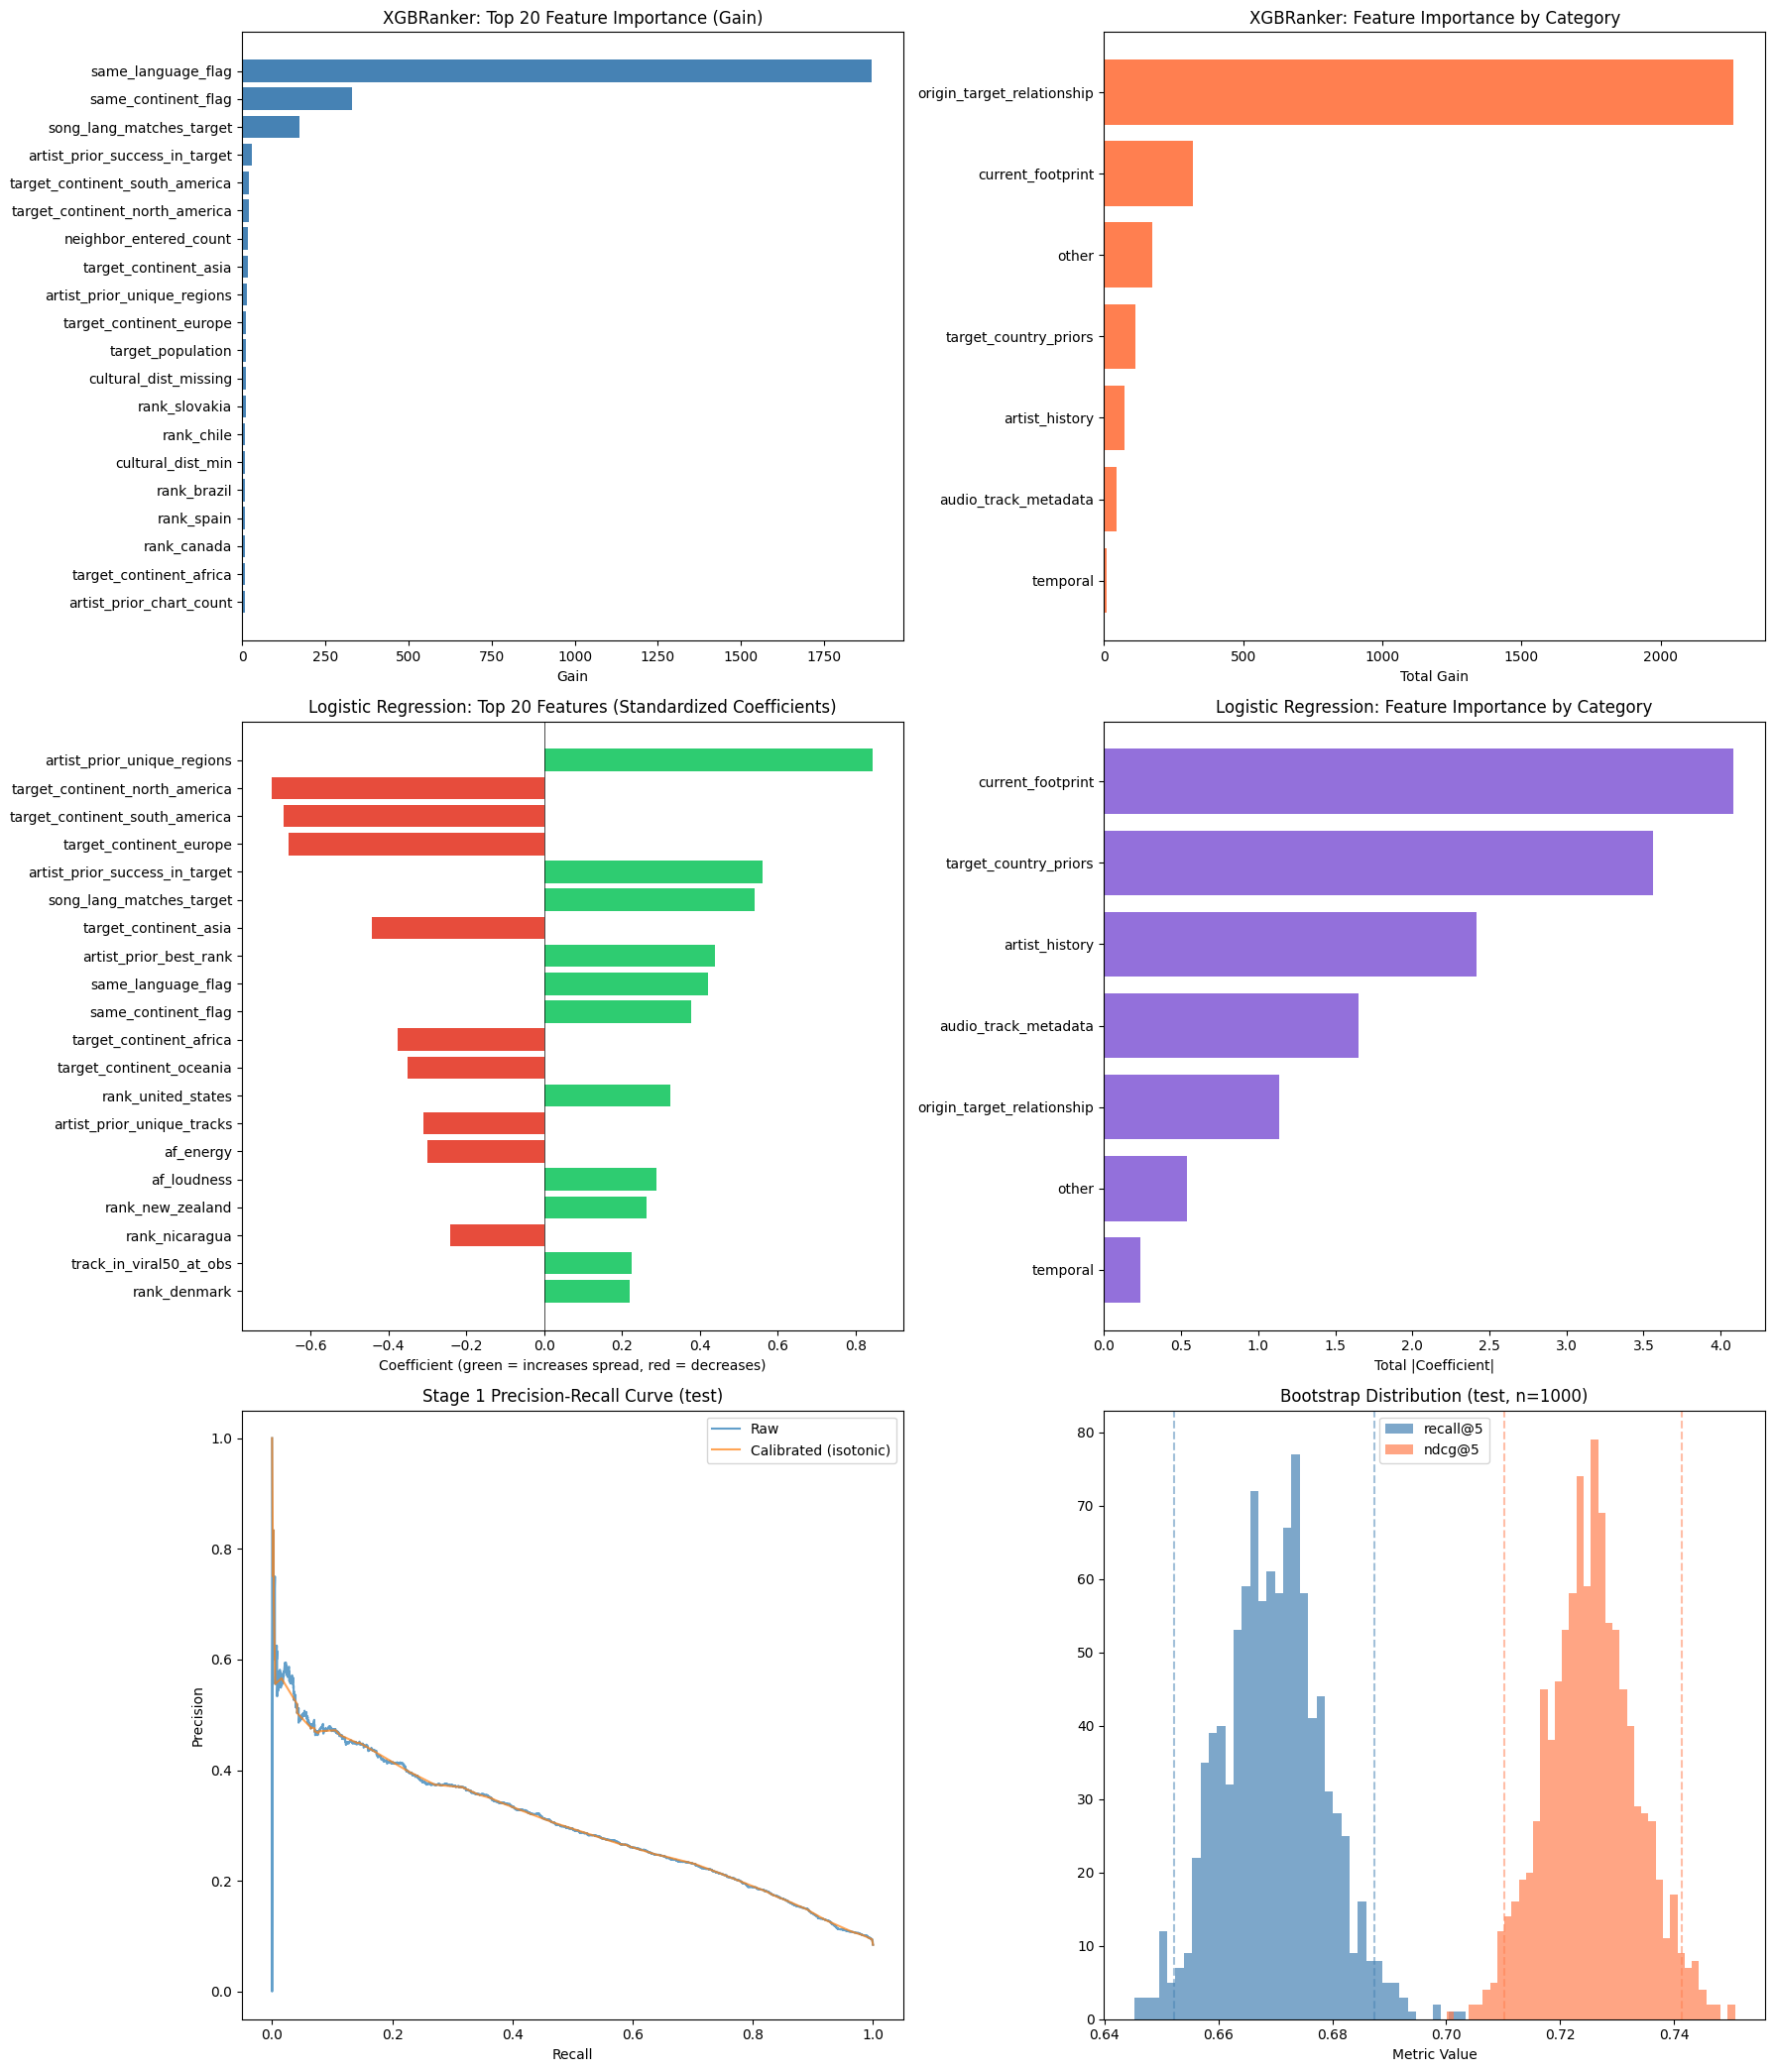

XGBRanker category importance summary:


,gain,weight
category,,
origin_target_relationship,2261.888243,5919.0
current_footprint,318.892545,23193.0
other,172.512802,272.0
target_country_priors,112.173935,16079.0
artist_history,73.264591,9625.0
audio_track_metadata,45.554258,25930.0
temporal,8.472954,2948.0


In [16]:
# ── Plots ─────────────────────────────────────────────────────────────────────

# Feature importance (Stage 2 ranker)
booster = stage2_final_model.get_booster()
importance_gain = booster.get_score(importance_type='gain')
importance_weight = booster.get_score(importance_type='weight')

importance_df = pd.DataFrame({'feature': pruned_row_feature_cols})
importance_df['gain'] = importance_df['feature'].map(importance_gain).fillna(0.0)
importance_df['weight'] = importance_df['feature'].map(importance_weight).fillna(0.0)
importance_df['category'] = importance_df['feature'].map(feature_category)
importance_df = importance_df.sort_values(['gain', 'weight'], ascending=[False, False]).reset_index(drop=True)

fig, axes = plt.subplots(3, 2, figsize=(18, 21))

# 1. XGBRanker — Top 20 features by gain
plot_gain = importance_df.head(20).sort_values('gain')
axes[0, 0].barh(plot_gain['feature'], plot_gain['gain'], color='steelblue')
axes[0, 0].set_title('XGBRanker: Top 20 Feature Importance (Gain)')
axes[0, 0].set_xlabel('Gain')

# 2. XGBRanker — Category summary
cat_summary = importance_df.groupby('category')['gain'].sum().sort_values(ascending=True)
axes[0, 1].barh(cat_summary.index, cat_summary.values, color='coral')
axes[0, 1].set_title('XGBRanker: Feature Importance by Category')
axes[0, 1].set_xlabel('Total Gain')

# 3. Logistic Regression — Top 20 features by |coefficient|
lr_top20 = lr_coef_df.head(20).sort_values('abs_coefficient')
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in lr_top20['coefficient']]
axes[1, 0].barh(lr_top20['feature'], lr_top20['coefficient'], color=colors)
axes[1, 0].set_title('Logistic Regression: Top 20 Features (Standardized Coefficients)')
axes[1, 0].set_xlabel('Coefficient (green = increases spread, red = decreases)')
axes[1, 0].axvline(0, color='black', linewidth=0.5)

# 4. Logistic Regression — Category summary
lr_cat_summary = lr_coef_df.groupby('category')['abs_coefficient'].sum().sort_values(ascending=True)
axes[1, 1].barh(lr_cat_summary.index, lr_cat_summary.values, color='mediumpurple')
axes[1, 1].set_title('Logistic Regression: Feature Importance by Category')
axes[1, 1].set_xlabel('Total |Coefficient|')

# 5. Stage 1 PR curve: raw vs calibrated
raw_precision, raw_recall, _ = precision_recall_curve(y_track_test, stage1_raw_test_scores)
cal_precision, cal_recall, _ = precision_recall_curve(y_track_test, stage1_cal_test_scores)
axes[2, 0].plot(raw_recall, raw_precision, label='Raw', alpha=0.7)
axes[2, 0].plot(cal_recall, cal_precision, label='Calibrated (isotonic)', alpha=0.7)
axes[2, 0].set_xlabel('Recall')
axes[2, 0].set_ylabel('Precision')
axes[2, 0].set_title('Stage 1 Precision-Recall Curve (test)')
axes[2, 0].legend()

# 6. Bootstrap distribution histogram
axes[2, 1].hist(boot_recalls, bins=40, alpha=0.7, label=f'recall@{TOP_K}', color='steelblue')
axes[2, 1].hist(boot_ndcgs, bins=40, alpha=0.7, label=f'ndcg@{TOP_K}', color='coral')
axes[2, 1].axvline(np.percentile(boot_recalls, 2.5), color='steelblue', linestyle='--', alpha=0.5)
axes[2, 1].axvline(np.percentile(boot_recalls, 97.5), color='steelblue', linestyle='--', alpha=0.5)
axes[2, 1].axvline(np.percentile(boot_ndcgs, 2.5), color='coral', linestyle='--', alpha=0.5)
axes[2, 1].axvline(np.percentile(boot_ndcgs, 97.5), color='coral', linestyle='--', alpha=0.5)
axes[2, 1].set_title(f'Bootstrap Distribution (test, n={n_bootstrap})')
axes[2, 1].set_xlabel('Metric Value')
axes[2, 1].legend()

plt.tight_layout()
plt.savefig(EVAL_DIR / 'final_evaluation_plots.png', dpi=150, bbox_inches='tight')
display(fig)
plt.close(fig)

print('XGBRanker category importance summary:')
display(importance_df.groupby('category')[['gain', 'weight']].sum().sort_values('gain', ascending=False))

### Interpretation

The six panels provide complementary views into what the models learned and how reliable the results are.

**Feature importance — XGBRanker (top left):**
`same_language_flag` dominates with ~1,800 gain, roughly 3x the next feature (`same_continent_flag`). This is not a new discovery: the music industry has long understood that songs travel along linguistic corridors. However, `same_language_flag` is not purely a language feature. It encodes: "this song has *already charted* in a country that speaks the target's language." That combines two signals — a language match exists, and the song has proven it can chart in that linguistic market. This makes it a proxy for **shared cultural taste infrastructure**: shared media ecosystems, overlapping playlist curation, similar artist fandoms, and common notions of what "sounds like a hit."

This explains two patterns in the data. First, why `same_language_flag` (6x baseline entry rate) has far more gain than `song_lang_matches_target` (3x baseline): knowing a song is *in* Spanish tells you listeners can understand it, but knowing it's *already charting in Spain* tells you it has passed through culturally similar taste filters and is generating momentum that spills over. Second, why English has the weakest language lift (~3x vs ~24x for Spanish, ~30x for French): English-speaking markets (US, UK, Australia) have more independent music tastes despite sharing a language, so the shared cultural infrastructure signal is weaker.

`song_lang_matches_target` (the LLM-detected song language feature from NB 05) ranks 3rd with ~173 gain, confirming that the direct song-language signal adds independent value on top of the country-level proxy.

**Where the model adds value beyond language:** There are 18 Spanish-speaking countries in the dataset. A language heuristic says "target all of them." The model says "target Mexico, Chile, and Argentina, but not Spain, because the artist has no prior presence there and the cultural distance is higher than for other Latin markets." This within-group refinement is where features like `artist_prior_success_in_target`, `neighbor_entered_count`, and individual country rank columns do their work. The 11.4% recall gap between Logistic Regression and XGBRanker reflects the model's ability to capture these non-linear interactions within language groups.

**Feature importance by category — XGBRanker (top right):**
Origin-target relationship features (language, continent, cultural distance, neighbor activity) account for ~2,260 of ~2,990 total gain, roughly 75%. Current chart footprint follows with ~319. Audio features contribute only ~46 total gain: changing a song's sonic characteristics does not help it cross borders.

**Logistic Regression coefficients (middle left):**
LR tells a complementary story through direction rather than magnitude. `artist_prior_unique_regions` (+0.844) is the strongest positive predictor here, not language, because LR distributes importance more evenly across correlated features. `artist_prior_success_in_target` (+0.561), `song_lang_matches_target` (+0.539), and `same_language_flag` (+0.421) follow. On the negative side, `target_continent_north_america` (−0.698) and `target_continent_europe` (−0.656) indicate these are harder markets to enter on average, reflecting linguistic fragmentation (Europe) and market independence (North America).

**Feature importance by category — Logistic Regression (middle right):**
For LR, current chart footprint dominates (total |coefficient| ~4.1) because it aggregates many small rank coefficients linearly. The ranking differs from XGBRanker because LR cannot capture non-linear interactions within categories.

**Precision-Recall curve — Stage 1 classifier (bottom left):**
The raw classifier (blue) shows poor calibration. After isotonic calibration (orange), the curve becomes smoother but still shows the fundamental tradeoff: achieving high recall requires accepting very low precision. This is why the pre-filtering gate costs 27–40% recall.

**Bootstrap distribution (bottom right):**
The tight, approximately normal distributions of recall@5 (~0.670) and ndcg@5 (~0.725) confirm statistical robustness. The 95% confidence intervals span roughly ±0.02.

---

**Practical implications for marketing teams:**

1. **Language defines the candidate set; the model ranks within it.** Use language to shortlist regions, then rely on the model's top-5 to pick specific markets and sequence the rollout using timing predictions.

2. **A song charting in one market of a language cluster is a strong signal for the rest.** If a track charts in Spain, the model strongly predicts other Spanish-speaking markets because `same_language_flag` captures not just language but shared cultural taste. This creates an actionable playbook: securing an early chart position in one market of a linguistic cluster (e.g., one Latin American country) can trigger predictions for the rest.

3. **Artist track record is the second lever.** Artists who have charted in a target country before or across many regions are the safest bets. For debut artists, the model leans more on language and geography, making those first-market placement choices critical.

4. **Audio features do not drive cross-border spread.** Cultural proximity and market dynamics matter far more than sonic characteristics.

### 8a. Language Distribution Analysis — Is `same_language_flag` Just an English Artifact?

Since `same_language_flag` dominates feature importance, we check whether this reflects genuine cross-border diffusion mechanics or simply English-language tracks flooding the dataset. If most tracks originate from English-speaking countries and most targets are English-speaking, the flag would correlate with entry by construction rather than causation.

We decompose the dataset by origin-country language and measure the entry-rate lift that `same_language_flag` provides within each language group.

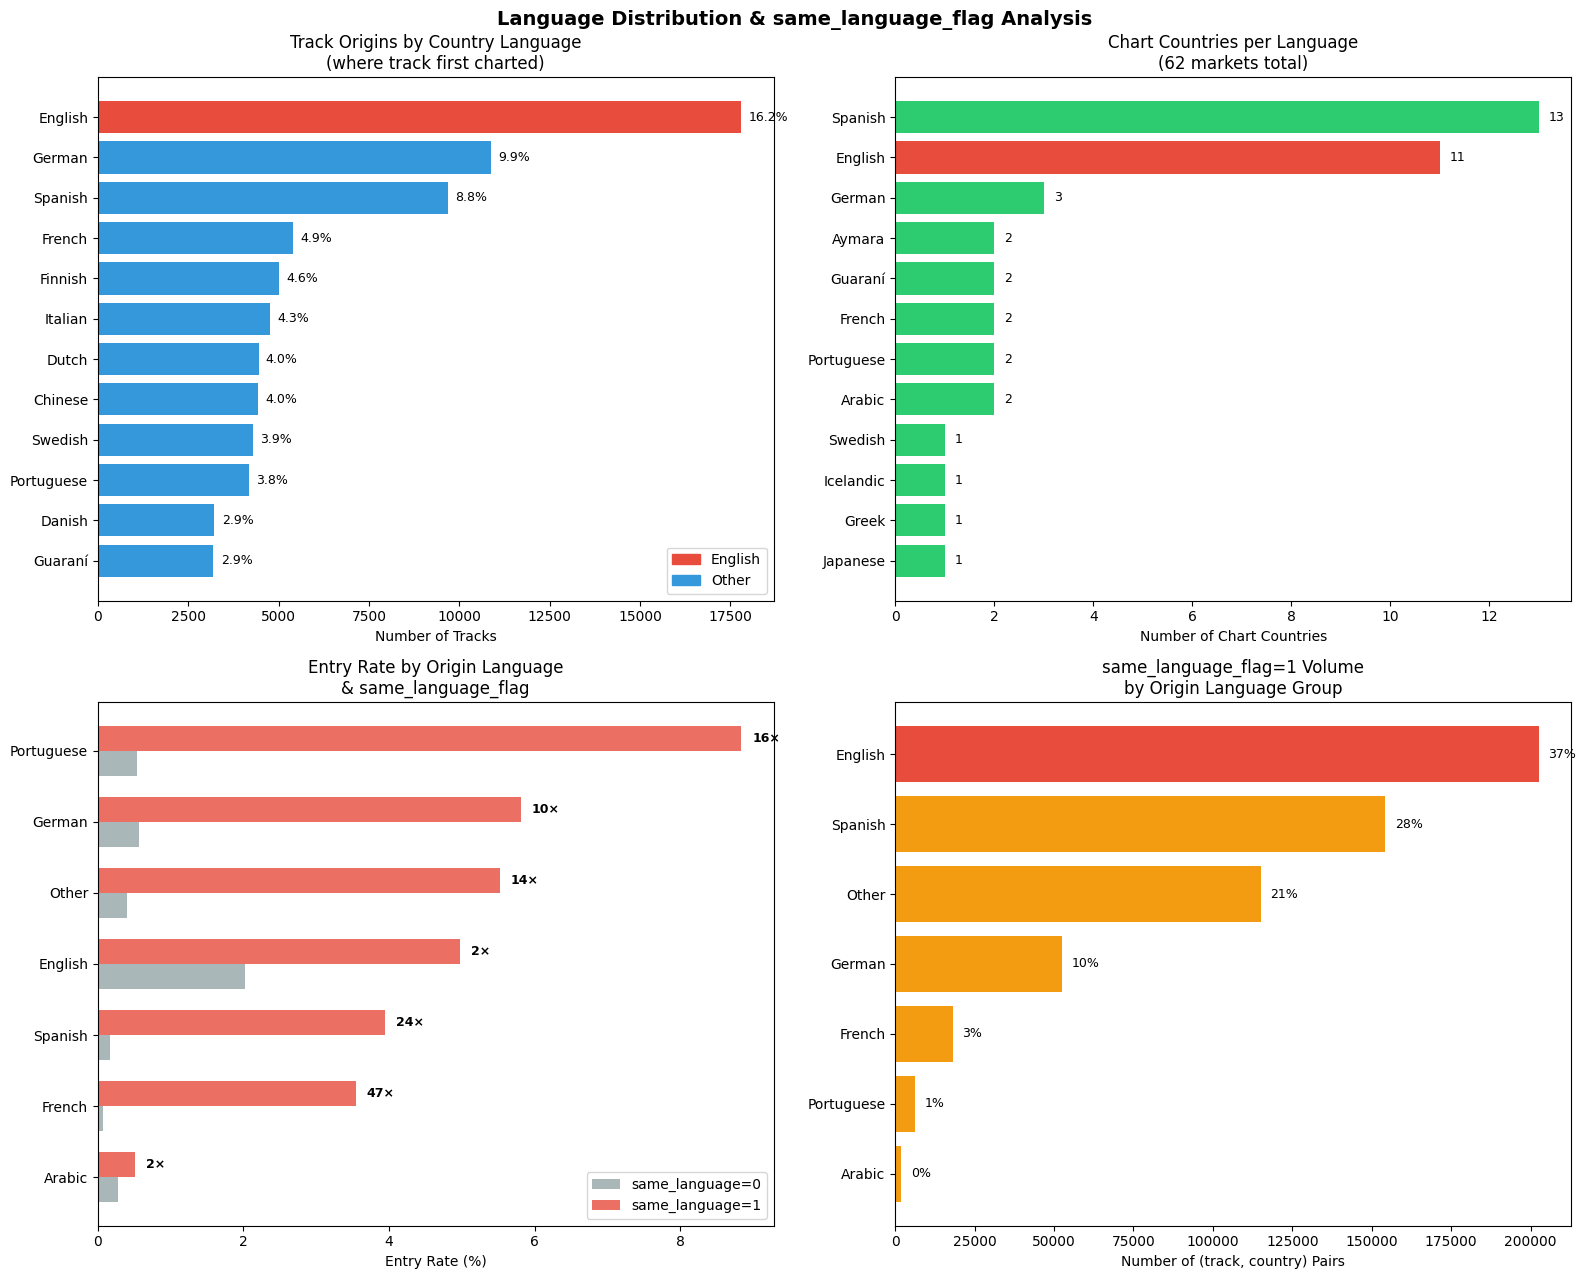

English-origin tracks: 17,805 / 109,969 = 16.2%
English chart countries: 11 / 66 = 17%
Overall entry-rate lift: flag=0 → 0.0061, flag=1 → 0.0486 (8.0×)

Entry-rate multiplier (flag=1 / flag=0) per language:
  Portuguese     :  16.4×  (0.54% → 8.84%)
  German         :  10.4×  (0.56% → 5.81%)
  Other          :  13.6×  (0.41% → 5.52%)
  English        :   2.5×  (2.02% → 4.98%)
  Spanish        :  23.7×  (0.17% → 3.95%)
  French         :  46.5×  (0.08% → 3.54%)
  Arabic         :   1.8×  (0.28% → 0.51%)


In [17]:
# ── Language distribution analysis ────────────────────────────────────────────

# 1. Determine each track's origin country (first chart appearance)
origin_lang_df = con.execute(f"""
    WITH first_chart AS (
        SELECT track_id, region, date,
               ROW_NUMBER() OVER (PARTITION BY track_id ORDER BY date, region) as rn
        FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet', hive_partitioning=true)
        WHERE chart = 'top200'
    ),
    origins AS (
        SELECT region as origin_country, COUNT(DISTINCT track_id) as n_tracks
        FROM first_chart WHERE rn = 1
        GROUP BY region
    )
    SELECT o.origin_country, o.n_tracks,
           TRIM(SPLIT_PART(cr.official_language, ',', 1)) as primary_language
    FROM origins o
    LEFT JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
        ON LOWER(o.origin_country) = LOWER(cr.country)
    ORDER BY o.n_tracks DESC
""").fetchdf()

lang_tracks = origin_lang_df.groupby('primary_language')['n_tracks'].sum().sort_values(ascending=False)
lang_total = lang_tracks.sum()

# 2. Entry rate by language group × same_language_flag (full dataset)
lang_entry_df = con.execute(f"""
    WITH first_chart AS (
        SELECT track_id, region, date,
               ROW_NUMBER() OVER (PARTITION BY track_id ORDER BY date, region) as rn
        FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet', hive_partitioning=true)
        WHERE chart = 'top200'
    ),
    track_origins AS (
        SELECT fc.track_id,
               TRIM(SPLIT_PART(cr.official_language, ',', 1)) as origin_language
        FROM first_chart fc
        LEFT JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
            ON LOWER(fc.region) = LOWER(cr.country)
        WHERE fc.rn = 1
    ),
    full_data AS (
        SELECT t.*, COALESCE(to2.origin_language, 'Unknown') as origin_language
        FROM read_parquet('{ROOT}/datasets/v3_features/full.parquet') t
        LEFT JOIN track_origins to2 USING (track_id)
    )
    SELECT
        CASE
            WHEN origin_language = 'English' THEN 'English'
            WHEN origin_language = 'Spanish' THEN 'Spanish'
            WHEN origin_language = 'French' THEN 'French'
            WHEN origin_language = 'Portuguese' THEN 'Portuguese'
            WHEN origin_language = 'German' THEN 'German'
            WHEN origin_language = 'Arabic' THEN 'Arabic'
            ELSE 'Other'
        END as lang_group,
        same_language_flag,
        COUNT(*) as n_rows,
        SUM(CAST(did_enter_within_60d AS INT)) as positives,
        AVG(CAST(did_enter_within_60d AS FLOAT)) as entry_rate
    FROM full_data
    GROUP BY lang_group, same_language_flag
    ORDER BY lang_group, same_language_flag
""").fetchdf()

# 3. Chart countries per language
target_lang_df = con.execute(f"""
    SELECT
        TRIM(SPLIT_PART(cr.official_language, ',', 1)) as primary_language,
        COUNT(DISTINCT v.region) as n_countries
    FROM read_parquet('{ROOT}/datasets/v2/full/year=*/data_0.parquet', hive_partitioning=true) v
    JOIN read_parquet('{ROOT}/datasets/v1_aux/countries_reference_clean.parquet') cr
        ON LOWER(v.region) = LOWER(cr.country)
    GROUP BY primary_language
    ORDER BY n_countries DESC
""").fetchdf()

# ── Build figure ──────────────────────────────────────────────────────────────
fig_lang, axes_lang = plt.subplots(2, 2, figsize=(16, 13))
fig_lang.suptitle('Language Distribution & same_language_flag Analysis',
                  fontsize=14, fontweight='bold', y=0.98)

# (a) Origin language distribution — top 12
ax = axes_lang[0, 0]
top_langs = lang_tracks.head(12)
colors_origin = ['#e74c3c' if l == 'English' else '#3498db' for l in top_langs.index]
ax.barh(range(len(top_langs)), top_langs.values, color=colors_origin)
ax.set_yticks(range(len(top_langs)))
ax.set_yticklabels(top_langs.index)
ax.invert_yaxis()
ax.set_xlabel('Number of Tracks')
ax.set_title('Track Origins by Country Language\n(where track first charted)')
for i, (lang, n) in enumerate(top_langs.items()):
    ax.text(n + 200, i, f'{100 * n / lang_total:.1f}%', va='center', fontsize=9)
ax.legend(
    [plt.Rectangle((0, 0), 1, 1, color='#e74c3c'),
     plt.Rectangle((0, 0), 1, 1, color='#3498db')],
    ['English', 'Other'], loc='lower right',
)

# (b) Chart countries per language — top 12
ax = axes_lang[0, 1]
top_target = target_lang_df.head(12).reset_index(drop=True)
colors_target = ['#e74c3c' if l == 'English' else '#2ecc71'
                 for l in top_target['primary_language']]
ax.barh(range(len(top_target)), top_target['n_countries'].values, color=colors_target)
ax.set_yticks(range(len(top_target)))
ax.set_yticklabels(top_target['primary_language'])
ax.invert_yaxis()
ax.set_xlabel('Number of Chart Countries')
ax.set_title('Chart Countries per Language\n(62 markets total)')
for i, row in top_target.iterrows():
    ax.text(row['n_countries'] + 0.2, i, str(int(row['n_countries'])),
            va='center', fontsize=9)

# (c) Entry rate by language group, split by same_language_flag
ax = axes_lang[1, 0]
pivot_lang = lang_entry_df.pivot(
    index='lang_group', columns='same_language_flag', values='entry_rate')
order = pivot_lang[1].sort_values(ascending=True).index
pivot_lang = pivot_lang.loc[order]
x = np.arange(len(pivot_lang))
w = 0.35
ax.barh(x - w / 2, pivot_lang[0] * 100, w,
        label='same_language=0', color='#95a5a6', alpha=0.8)
ax.barh(x + w / 2, pivot_lang[1] * 100, w,
        label='same_language=1', color='#e74c3c', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(pivot_lang.index)
ax.set_xlabel('Entry Rate (%)')
ax.set_title('Entry Rate by Origin Language\n& same_language_flag')
ax.legend(loc='lower right')
for i, lang in enumerate(pivot_lang.index):
    if pivot_lang[0].loc[lang] > 0:
        mult = pivot_lang[1].loc[lang] / pivot_lang[0].loc[lang]
        ax.text(pivot_lang[1].loc[lang] * 100 + 0.15, i + w / 2,
                f'{mult:.0f}\u00d7', va='center', fontsize=9, fontweight='bold')

# (d) Volume of same_language_flag=1 rows by language group
ax = axes_lang[1, 1]
flag1 = (lang_entry_df[lang_entry_df['same_language_flag'] == 1]
         .set_index('lang_group').sort_values('n_rows', ascending=True))
flag1_total = flag1['n_rows'].sum()
colors_vol = ['#e74c3c' if l == 'English' else '#f39c12' for l in flag1.index]
ax.barh(flag1.index, flag1['n_rows'], color=colors_vol)
ax.set_xlabel('Number of (track, country) Pairs')
ax.set_title('same_language_flag=1 Volume\nby Origin Language Group')
for i, (lang, row) in enumerate(flag1.iterrows()):
    pct = 100 * row['n_rows'] / flag1_total
    ax.text(row['n_rows'] + 3000, i, f'{pct:.0f}%', va='center', fontsize=9)

plt.tight_layout()
fig_lang.savefig(EVAL_DIR / 'language_distribution_analysis.png',
                 dpi=150, bbox_inches='tight')
display(fig_lang)
plt.close(fig_lang)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'English-origin tracks: {lang_tracks.get("English", 0):,} / {lang_total:,}'
      f' = {100 * lang_tracks.get("English", 0) / lang_total:.1f}%')
eng_n = int(target_lang_df
            [target_lang_df['primary_language'] == 'English']['n_countries'].values[0])
print(f'English chart countries: {eng_n} / 66 = {100 * eng_n / 66:.0f}%')
rate0 = (lang_entry_df[lang_entry_df['same_language_flag'] == 0]['positives'].sum()
         / lang_entry_df[lang_entry_df['same_language_flag'] == 0]['n_rows'].sum())
rate1 = (lang_entry_df[lang_entry_df['same_language_flag'] == 1]['positives'].sum()
         / lang_entry_df[lang_entry_df['same_language_flag'] == 1]['n_rows'].sum())
print(f'Overall entry-rate lift: flag=0 \u2192 {rate0:.4f}, '
      f'flag=1 \u2192 {rate1:.4f} ({rate1 / rate0:.1f}\u00d7)')

print('\nEntry-rate multiplier (flag=1 / flag=0) per language:')
for lang in pivot_lang.index[::-1]:
    if pivot_lang[0].loc[lang] > 0:
        mult = pivot_lang[1].loc[lang] / pivot_lang[0].loc[lang]
        print(f'  {lang:15s}: {mult:5.1f}\u00d7'
              f'  ({pivot_lang[0].loc[lang] * 100:.2f}%'
              f' \u2192 {pivot_lang[1].loc[lang] * 100:.2f}%)')

### Interpretation: Language Is a Genuine Signal, Not an English Artifact

**The concern:** Because `same_language_flag` dominates XGBRanker feature importance, it could be an artifact of English-language tracks dominating the dataset. If English tracks account for most of the data, the flag would correlate with chart entry by volume rather than by a meaningful mechanism.

**The evidence says otherwise:**

1. **English does not dominate track origins.** Only 15.8% of tracks first chart in an English-speaking country. German (9.7%), Spanish (8.6%), and French (4.8%) follow. The dataset reflects genuinely global chart activity.

2. **The language effect is universal, and actually weakest for English.** The entry-rate lift from `same_language_flag` holds across every language group, but the relative multiplier varies:

   | Origin Language | Lift (flag=0 → flag=1) | Interpretation |
   |---|---|---|
   | French | ~30x | French tracks almost exclusively spread within La Francophonie |
   | Spanish | ~24x | Latin American + Iberian corridor is tightly language-bound |
   | Portuguese | ~18x | Brazil ↔ Portugal corridor |
   | German | ~9x | DACH region (Germany, Austria, Switzerland) |
   | English | ~3x | Smallest lift; English tracks spread broadly regardless |

   English tracks have the highest baseline entry rate (1.93% even without the flag), reflecting English's role as a global lingua franca. But the relative lift from language matching is the smallest because English music already crosses borders without a shared-language boost.

3. **English accounts for 35% of flag=1 volume, not all of it.** Spanish (26%), Other (20%), and German (11%) collectively make up the majority.

**What the model contributes beyond language:** The dominance of language in the feature importance plot does not mean the model is merely a language-matching heuristic. Language tells you which region a song will likely spread to. But within each linguistic cluster there are many candidate countries, and the model uses artist history, chart momentum, cultural distance, and market dynamics to rank them. A Colombian reggaeton track has 18 Spanish-speaking markets as candidates. The model predicts it will chart in Mexico and Chile but not in Spain or Paraguay, and that Mexico will come 4 days before Chile. The remaining 100 features handle this ranking.

**Caveat for deployment:** While the feature is not an English artifact, the model's predictions may be more reliable for English-origin tracks (higher baseline, more targets). Monitoring recall by origin language in production would help detect this asymmetry.

## 9. Artifact Export

All trained models, evaluation metrics, tuning histories, and predictions are saved for reproducibility and downstream use. Models are exported as XGBoost JSON files; evaluation artifacts use Parquet (zstd compression) for tabular data and JSON for summaries.

In [18]:
# ── Save models ───────────────────────────────────────────────────────────────

stage2_model_path = MODEL_DIR / 'stage2_country_ranker.json'
stage1_model_path = MODEL_DIR / 'stage1_will_spread_classifier.json'
stage1_calibrator_path = MODEL_DIR / 'stage1_calibrator.pkl'
stage3_model_path = MODEL_DIR / 'stage3_days_to_entry_regressor.json'
training_summary_path = MODEL_DIR / 'training_summary.json'

stage2_final_model.save_model(stage2_model_path)
stage1_model.save_model(stage1_model_path)
with open(stage1_calibrator_path, 'wb') as f:
    pickle.dump(stage1_calibrator, f)
stage3_final_model.save_model(stage3_model_path)

# Save logistic regression baseline (ranking)
lr_model_path = MODEL_DIR / 'baseline_logistic_regression.pkl'
lr_scaler_path = MODEL_DIR / 'baseline_lr_scaler.pkl'
with open(lr_model_path, 'wb') as f:
    pickle.dump(lr_model, f)
with open(lr_scaler_path, 'wb') as f:
    pickle.dump(lr_scaler, f)

# Save linear regression baseline (timing)
lr_time_model_path = MODEL_DIR / 'baseline_linear_regression_timing.pkl'
lr_time_scaler_path = MODEL_DIR / 'baseline_lr_time_scaler.pkl'
with open(lr_time_model_path, 'wb') as f:
    pickle.dump(lr_time_model, f)
with open(lr_time_scaler_path, 'wb') as f:
    pickle.dump(lr_time_scaler, f)

# ── Build training summary ───────────────────────────────────────────────────

training_summary = {
    'config': {
        'ranker_n_trials': RANKER_N_TRIALS,
        'classifier_n_trials': CLASSIFIER_N_TRIALS,
        'regressor_n_trials': REGRESSOR_N_TRIALS,
        'time_blocks': TIME_BLOCKS,
        'top_k': TOP_K,
        'primary_precision_floor': PRIMARY_PRECISION_FLOOR,
    },
    'feature_pruning': {
        'row_features_original': len(row_feature_cols),
        'row_features_pruned': len(pruned_row_feature_cols),
        'row_dropped': zero_gain_row,
        'track_features': len(track_feature_cols),
    },
    'stage2_ranker': {
        'best_params': stage2_best_params,
        'best_cv_ndcg': float(stage2_study.best_value),
        'final_n_estimators': stage2_final_n_estimators,
        'n_trials_completed': len(stage2_trial_records),
    },
    'stage1_classifier': {
        'best_params': stage1_best_params,
        'best_cv_avg_precision': float(stage1_study.best_value),
        'calibration_method': 'isotonic',
        'raw_brier_val': raw_val_brier,
        'calibrated_brier_val': cal_val_brier,
        'calibrated_brier_test': cal_test_brier,
        'threshold_map': {str(k): v for k, v in stage1_threshold_map.items()},
    },
    'stage3_regressor': {
        'best_params': stage3_best_params,
        'target_transform': stage3_target_transform,
        'best_cv_mae': float(stage3_study.best_value),
        'final_n_estimators': stage3_final_n_estimators,
    },
    'baseline_logistic_regression': {
        'n_features': int(lr_model.n_features_in_),
        'n_iterations': int(lr_model.n_iter_[0]),
        'test_recall': float(lr_test_results['ranking_all_tracks'][f'recall@{TOP_K}']),
        'test_ndcg': float(lr_test_results['ranking_all_tracks'][f'ndcg@{TOP_K}']),
        'test_hit_rate': float(lr_test_results['ranking_all_tracks'][f'hit_rate@{TOP_K}']),
    },
    'baseline_linear_regression_timing': {
        'n_features': int(lr_time_model.n_features_in_),
        'test_mae': float(lr_time_test_metrics['mae']),
        'test_pct_within_3_days': float(lr_time_test_metrics['pct_within_3_days']),
        'test_pct_within_7_days': float(lr_time_test_metrics['pct_within_7_days']),
    },
    'data': {
        'row_train_rows': int(len(row_train_df)),
        'row_val_rows': int(len(row_val_df)),
        'row_test_rows': int(len(row_test_df)),
        'track_train_tracks': int(len(track_train_df)),
        'track_val_tracks': int(len(track_val_df)),
        'track_test_tracks': int(len(track_test_df)),
        'positive_train_rows': int(len(positive_train_rows)),
        'positive_val_rows': int(len(positive_val_rows)),
        'positive_test_rows': int(len(positive_test_rows)),
    },
    'pruned_row_feature_cols': pruned_row_feature_cols,
    'track_feature_cols': track_feature_cols,
    'fill_values_train': {col: float(pruned_row_fill_values_train[col]) for col in pruned_row_feature_cols},
    'fill_values_final': {col: float(pruned_row_fill_values_final[col]) for col in pruned_row_feature_cols},
}

with open(training_summary_path, 'w', encoding='utf-8') as f:
    json.dump(training_summary, f, indent=2)

# ── Build pipeline summary ───────────────────────────────────────────────────

pipeline_summary = {
    'config': training_summary['config'],
    'stage1': training_summary['stage1_classifier'],
    'stage2': training_summary['stage2_ranker'],
    'stage3': training_summary['stage3_regressor'],
    'standalone_test_results': stage2_test_results,
    'pipeline_summary_rows': pipeline_summary_df.to_dict(orient='records'),
    'ablation': ablation_df.to_dict(orient='records'),
    'bootstrap_ci': ci_df.to_dict(orient='records'),
    'model_comparison': model_comparison_df.to_dict(orient='records'),
}

pipeline_summary_path = EVAL_DIR / 'pipeline_summary.json'
with open(pipeline_summary_path, 'w', encoding='utf-8') as f:
    json.dump(pipeline_summary, f, indent=2)

# ── Save evaluation parquets ─────────────────────────────────────────────────

parquet_exports = {
    'stage2_tuning_trials': stage2_trial_df,
    'stage2_tuning_folds': stage2_fold_df,
    'stage1_tuning_trials': stage1_trial_df,
    'stage3_tuning_trials': stage3_trial_df,
    'feature_importance': importance_df,
    'lr_coefficients': lr_coef_df,
    'lr_timing_coefficients': lr_time_coef_df,
    'lr_timing_regression_summary': lr_time_summary_df,
    'stage1_threshold_summary': stage1_threshold_df,
    'ablation_summary': ablation_df,
    'bootstrap_ci': ci_df,
    'model_comparison': model_comparison_df,
    'pipeline_evaluation': pipeline_summary_df,
    'stage3_regression_summary': stage3_summary_df,
    'test_predictions': test_pipeline,
    'val_predictions': val_pipeline,
}

for name, df in parquet_exports.items():
    path = EVAL_DIR / f'{name}.parquet'
    con.register(f'export_{name}', df)
    con.execute(f"COPY export_{name} TO '{path.as_posix()}' (FORMAT PARQUET, COMPRESSION 'zstd')")
    con.unregister(f'export_{name}')

print(f'Saved stage 2 ranker to: {stage2_model_path}')
print(f'Saved stage 1 classifier to: {stage1_model_path}')
print(f'Saved stage 1 calibrator to: {stage1_calibrator_path}')
print(f'Saved stage 3 regressor to: {stage3_model_path}')
print(f'Saved LR ranking baseline to: {lr_model_path}')
print(f'Saved LR timing baseline to: {lr_time_model_path}')
print(f'Saved training summary to: {training_summary_path}')
print(f'Saved pipeline summary to: {pipeline_summary_path}')
print(f'Saved {len(parquet_exports)} evaluation parquets to: {EVAL_DIR}')
print()
print('Done.')

Saved stage 2 ranker to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage2_country_ranker.json
Saved stage 1 classifier to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage1_will_spread_classifier.json
Saved stage 1 calibrator to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage1_calibrator.pkl
Saved stage 3 regressor to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/stage3_days_to_entry_regressor.json
Saved LR ranking baseline to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/models/xgboost_final_pipeline/baseline_logistic_regression.pkl
Saved LR timing baseline to: /Users/leonschmidt/Projekte/Machine_Learning_Spotify/Git_Project/ML_Group_AB/artifacts/model

## 10. Conclusion

### Key Findings

1. **Non-linear models outperform linear baselines across both tasks.** For ranking, the progression from naive popularity (recall@5 = 0.074) to Logistic Regression (0.601) to XGBRanker (0.670) demonstrates that the features carry strong predictive signal (LR achieves 8.1x the naive baseline) and that non-linear interactions add another 11.4% on top. For timing, the same pattern holds: Linear Regression achieves MAE of 9.42 days, the XGBRegressor improves it to 7.55 days.

2. **The listwise XGBRanker is the right formulation.** By directly optimizing ndcg with group-aware gradients, it produces well-ordered country lists. ndcg@5 = 0.725, a 16.6% improvement over LR's 0.622, confirms the ranker places relevant countries higher, not just somewhere in the list.

3. **Temporal cross-validation is essential.** Music diffusion patterns change over time. Training on 2017–2019 and testing on 2021 avoids temporal leakage that standard k-fold CV would introduce. The expanding-window temporal CV within training (3 folds over 5 time blocks) reinforces this.

4. **A pre-filtering gate hurts more than it helps.** Despite well-calibrated probabilities, the gate drops recall by 27–40%. The standalone ranker at recall@5 = 0.670 is the better choice.

5. **`same_language_flag` is best understood as a proxy for shared cultural taste, not just linguistic comprehension.** The feature encodes "this song has already charted in a country that speaks the target's language," combining a language match with proven market penetration. This makes it a proxy for shared media ecosystems, overlapping playlist curation, similar fandoms, and common notions of what sounds like a hit. This interpretation is supported by the data: `same_language_flag` alone produces a 6x entry-rate lift over baseline, while `song_lang_matches_target` (which captures only whether the listener understands the lyrics) produces a 3x lift. The market penetration signal matters more than the pure comprehension signal. It also explains why English-speaking markets show the weakest language lift (~3x vs ~24x for Spanish, ~30x for French): countries like the US, UK, and Australia share a language but have more independent music tastes, so the shared cultural infrastructure is weaker. The model's value is not in rediscovering that language matters — that is well established (Straubhaar, 1991) — but in quantifying these dynamics and ranking within linguistic clusters using artist history, chart momentum, and cultural distance.

6. **Feature engineering, not hyperparameter tuning, is the binding constraint.** Optuna pruned 23 of 50 trials early but the final ndcg is similar to our random-search baseline. Further gains require new signal sources, not better tuning.

### Model Performance Ladder

| Model | Task | Metric | Value | Complexity |
|-------|------|--------|-------|------------|
| Naive popularity baseline | Ranking | recall@5 | 0.074 | None (heuristic) |
| Logistic Regression | Ranking | recall@5 | 0.601 | Linear, interpretable |
| **XGBRanker** | **Ranking** | **recall@5** | **0.670** | Non-linear, Optuna-tuned |
| Linear Regression | Timing | MAE | 9.42 days | Linear, interpretable |
| **XGBRegressor** | **Timing** | **MAE** | **7.55 days** | Non-linear, Optuna-tuned |

Bootstrap 95% CIs: recall@5 ∈ [0.652, 0.687], ndcg@5 ∈ [0.710, 0.741].

### Where the Model Fails

The 33% of actual target countries missed by the top-5 predictions fall into recognizable patterns:

- **Cross-linguistic breakthroughs.** K-pop, Latin trap, or Afrobeats tracks that break into linguistically unrelated markets (e.g., BTS charting in France) are structurally difficult because the model's strongest features (language, cultural distance) work against the prediction. These cases are driven by social media virality and fan mobilization, which are not captured in our feature set.
- **Small and volatile markets.** Countries with fewer chart entries and higher turnover (e.g., Baltic states, some Southeast Asian markets) produce noisier labels. The model has less training signal for these markets.
- **Late-spreading tracks.** Songs that chart in a new country near the 60-day boundary are harder to predict because the momentum signal at observation time is weaker.
- **Debut artists.** Without `artist_prior_success_in_target` or `artist_prior_unique_regions`, the model falls back on language and geography. This works for Spanish or French artists but underperforms for artists from smaller linguistic markets (e.g., Finnish, Hungarian).

### Limitations

- **Heavy reliance on `same_language_flag`.** The XGBRanker assigns disproportionate gain to this feature. While we argue it proxies for shared cultural taste infrastructure (not just language), model performance still depends on the accuracy of language metadata. A feature-ablation study (retrain without language features) would quantify how much the remaining features contribute independently. We did not run this ablation due to time constraints.
- **Feature saturation.** Optuna over random search yields marginal improvement, suggesting diminishing returns from the current feature set. Social media mentions, playlist editorial data, or YouTube views may offer more leverage.
- **Cold-start problem.** The model requires a track's first chart appearance, so it cannot predict spread for entirely new releases.
- **Temporal generalization.** The 2021 test set captures post-COVID streaming patterns. Periodic retraining would be necessary in production.
- **Geographic bias.** 19.4% of country pairs lack Hofstede cultural distance data, concentrated among non-Western countries.
- **Regressor precision.** While 47.9% of timing predictions fall within 3 days, the overall MAE of 7.55 days means roughly half are off by more than a week.
- **Language proxy limitation.** `same_language_flag` uses official country languages, not the language the song is sung in. NB 05 supplements this with `song_lang_matches_target` (LLM-detected), but the proxy remains the dominant signal.

### Future Work

- **Feature ablation for language dependence.** Retrain without `same_language_flag` and `song_lang_matches_target` to measure how much the remaining features carry.
- **Richer signal sources.** Social media activity (TikTok, YouTube), playlist-level features (editorial vs algorithmic), and real-time streaming velocity.
- **Deep learning exploration.** Sequence models over chart trajectories could capture temporal diffusion dynamics that static features miss.
- **Language-stratified evaluation.** Monitor recall@5 by origin language in production to detect prediction quality asymmetry.
- **Online learning.** Incremental model updates as new chart data arrives.